# Análise de resultados dos modelos e avaliação do CPOD

In [1]:
library(MASS)     # para fitdistr e binomial negativa
library(tidyverse)
library(dplyr)
library(ggplot2)
library(stringr)
library(tidyr)
library(purrr)
library(scales)
library(fitdistrplus)  # para ajustar e comparar distribuições
library(broom)
library(lme4)
library(broom.mixed)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   4.0.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


Loading required package: survival

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




### Funções

In [2]:
# Verifica alinhamento por cd_exame
check_alignment <- function(gabarito, predicao) {
  if (!all(gabarito$cd_exame == predicao$cd_exame)) {
    stop("As tabelas não estão alinhadas pelo cd_exame.")
  }
}

In [3]:
# Seleciona colunas por prefixo (ex.: "ausente", "carie", "obturado")
select_tooth_cols <- function(data, prefix) {
  patt <- paste0("^", prefix, "_\\d{2}$")
  grep(patt, names(data), value = TRUE)
}

In [4]:
# Converte qualquer coluna para inteiro de forma segura, preservando contagens
to_int <- function(x) {
  # tenta converter para numérico
  if (is.numeric(x)) return(as.integer(round(x)))
  
  # trata casos com strings numéricas, vírgulas, etc.
  lx <- trimws(tolower(as.character(x)))
  lx <- str_replace_all(lx, ",", ".")
  
  # converte para número; valores não numéricos viram NA
  as.integer(suppressWarnings(as.numeric(lx)))
}

In [5]:
# Calcula métricas por dente para um prefixo, aceitando contagens e binarizando para métricas
metrics_by_tooth <- function(gabarito, predicao, prefix, binarize_threshold = 0L) {
  check_alignment(gabarito, predicao)

  cols_g <- select_tooth_cols(gabarito, prefix)
  cols_p <- select_tooth_cols(predicao, prefix)
  cols   <- intersect(cols_g, cols_p)
  if (length(cols) == 0) stop(sprintf("Nenhuma coluna encontrada para o prefixo '%s'.", prefix))

  gtmp <- gabarito[cols]
  ptmp <- predicao[cols]
  gtmp[] <- lapply(gtmp, to_int)
  ptmp[] <- lapply(ptmp, to_int)

  # Calcula as métricas para uma coluna
  calc_one <- function(col) {
      gt <- gtmp[[col]]
      pr <- ptmp[[col]]
      ok <- !(is.na(gt) | is.na(pr))
      gt <- gt[ok]; pr <- pr[ok]

      # binarização: presença se contagem > binarize_threshold
      gt_bin <- as.integer(gt > binarize_threshold)
      pr_bin <- as.integer(pr > binarize_threshold)

      tp <- sum(pr_bin == 1 & gt_bin == 1)
      tn <- sum(pr_bin == 0 & gt_bin == 0)
      fp <- sum(pr_bin == 1 & gt_bin == 0)
      fn <- sum(pr_bin == 0 & gt_bin == 1)
      n  <- length(gt_bin)

      precision <- if ((tp + fp) == 0) NA_real_ else tp / (tp + fp)
      recall    <- if ((tp + fn) == 0) NA_real_ else tp / (tp + fn)
      f1        <- if (is.na(precision) || is.na(recall) || (precision + recall) == 0) NA_real_ else 2 * precision * recall / (precision + recall)
      accuracy  <- (tp + tn) / n

      # prevalência verdadeira binária e médias de contagem (útil para inspeção)
      prevalence_gt   <- mean(gt_bin == 1)
      mean_count_gt   <- mean(gt, na.rm = TRUE)
      mean_count_pred <- mean(pr, na.rm = TRUE)

      tibble(
        target = prefix,
        coluna = col,
        dente  = as.integer(stringr::str_extract(col, "\\d{2}")),
        n, tp, fp, tn, fn,
        precision, recall, f1, accuracy,
        prevalence_gt, mean_count_gt, mean_count_pred
      )
    }

  purrr::map_dfr(cols, calc_one) %>% arrange(dente, coluna)
}

In [6]:
# Função para gerar gráfico por dente (F1 ou acurácia)
plot_metric_by_tooth <- function(resultado_por_dente, metric = c("f1", "accuracy"),
                                 title = NULL, color = "steelblue") {
  
  # Verifica se a métrica existe na tabela
  metric <- match.arg(metric)
  if (!metric %in% names(resultado_por_dente)) {
    stop(paste("Métrica", metric, "não encontrada no dataframe."))
  }
  
  # Ordem odontológica FDI
  ordem_fdi <- c(18,17,16,15,14,13,12,11,
                 21,22,23,24,25,26,27,28,
                 38,37,36,35,34,33,32,31,
                 41,42,43,44,45,46,47,48)
  
  # Prepara os dados
  resultado_plot <- resultado_por_dente %>%
    filter(dente %in% ordem_fdi) %>%
    mutate(dente = factor(dente, levels = ordem_fdi))
  
  # Define título padrão se não for informado
  if (is.null(title)) {
    title <- paste0(toupper(metric), " by tooth (FDI numbering)")
  }
  
  # Gera o gráfico
  ggplot(resultado_plot, aes(x = dente, y = .data[[metric]])) +
    geom_col(fill = color) +
    geom_text(
      aes(label = round(.data[[metric]], 2)),
      vjust = -0.3,
      size = 3.2
    ) +
    expand_limits(y = max(resultado_plot[[metric]], na.rm = TRUE) * 1.1) +
    labs(
      title = title,
      x = "Tooth (FDI numbering)",
      y = metric
    ) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1)
    )
}

In [7]:
# Função para calcular agregados macro e micro a partir da tabela por dente
aggregate_macro_micro <- function(resultado_por_dente) {
  
  # Agregado macro: média simples das métricas entre os dentes
  macro <- resultado_por_dente %>%
    summarise(
      precision = mean(precision, na.rm = TRUE),
      recall    = mean(recall,    na.rm = TRUE),
      f1        = mean(f1,        na.rm = TRUE),
      accuracy  = mean(accuracy,  na.rm = TRUE),
      description = "Average of metrics across all teeth (each tooth has equal weight)"
    ) %>%
    mutate(agg = "macro", .before = 1)
  
  # Agregado micro: todas as observações juntas (ponderadas pelo número de casos)
  micro_tp <- sum(resultado_por_dente$tp)
  micro_fp <- sum(resultado_por_dente$fp)
  micro_tn <- sum(resultado_por_dente$tn)
  micro_fn <- sum(resultado_por_dente$fn)
  
  micro_precision <- if ((micro_tp + micro_fp) == 0) NA_real_ else micro_tp / (micro_tp + micro_fp)
  micro_recall    <- if ((micro_tp + micro_fn) == 0) NA_real_ else micro_tp / (micro_tp + micro_fn)
  micro_f1        <- if (is.na(micro_precision) || is.na(micro_recall) || (micro_precision + micro_recall) == 0) NA_real_ else 2 * micro_precision * micro_recall / (micro_precision + micro_recall)
  micro_accuracy  <- (micro_tp + micro_tn) / (micro_tp + micro_fp + micro_tn + micro_fn)
  
  micro <- tibble(
    agg = "micro",
    precision = micro_precision,
    recall    = micro_recall,
    f1        = micro_f1,
    accuracy  = micro_accuracy,
    description = "Global metrics considering all teeth together (weighted by number of samples)"
  )
  
  # Combina os resultados
  resumo_global <- bind_rows(macro, micro)
  
  print("Resumo global (macro e micro):")
  print(resumo_global, n = Inf, width = Inf)
  
  return(resumo_global)
}

In [8]:
# Calcula, por exame, a contagem do alvo (prefixo_XX) no gabarito e na predição
compute_counts_by_exam <- function(gabarito, predicao, prefix) {
  stopifnot(all(gabarito$cd_exame == predicao$cd_exame))
  cols <- intersect(names(gabarito), names(predicao))
  cols_target <- grep(paste0("^", prefix, "_\\d{2}$"), cols, value = TRUE)
  if (length(cols_target) == 0) stop(sprintf("Nenhuma coluna encontrada para o prefixo '%s'.", prefix))

  gabarito[cols_target] <- lapply(gabarito[cols_target], as.integer)
  predicao[cols_target] <- lapply(predicao[cols_target], as.integer)

  tibble(
    cd_exame   = gabarito$cd_exame,
    count_gt   = rowSums(gabarito[cols_target], na.rm = TRUE),
    count_pred = rowSums(predicao[cols_target], na.rm = TRUE),
    prefix     = prefix
  ) %>%
    mutate(
      diff          = count_pred - count_gt,
      abs_diff      = abs(diff),
      correct_count = as.integer(count_pred == count_gt)
    )
}

In [9]:
# Sumariza métricas globais a partir da tabela de contagens por exame
summarize_count_metrics <- function(contagens) {
  contagens %>%
    summarise(
      prefix           = first(prefix),
      n_exames         = n(),
      exact_match_rate = mean(correct_count),
      mae              = mean(abs_diff),
      rmse             = sqrt(mean(diff^2)),
      bias             = mean(diff)
    )
}


In [10]:
# (Opcional) Gráfico scatter count_pred vs count_gt com diagonal y = x
plot_counts_scatter <- function(contagens, title = NULL) {
  if (is.null(title)) title <- paste0("Predicted vs True count (", first(contagens$prefix), ")")
  ggplot(contagens, aes(x = count_gt, y = count_pred)) +
    geom_point(alpha = 0.6, size = 2) +
    geom_abline(intercept = 0, slope = 1, linetype = "dashed") +
    coord_equal() +
    expand_limits(x = 0, y = 0) +
    labs(title = title, x = "True count", y = "Predicted count") +
    theme_minimal(base_size = 13)
  }

In [11]:
# Gera tabela de contingência + heatmap
contingency_table_counts <- function(contagens, normalize = FALSE) {
  
  # Cria a tabela de contingência
  tab <- contagens %>%
    count(count_gt, count_pred, name = "freq") %>%
    arrange(count_gt, count_pred)
  
  # Normaliza (opcional: mostra porcentagens em vez de contagem bruta)
  if (normalize) {
    total <- sum(tab$freq)
    tab <- tab %>%
      mutate(freq = freq / total,
             label = paste0(round(100 * freq, 1), "%"))
  } else {
    tab <- tab %>%
      mutate(label = as.character(freq))
  }
  
  # Gera o heatmap
  ggplot(tab, aes(x = count_gt, y = count_pred, fill = freq)) +
    geom_tile(color = "white") +
    geom_text(aes(label = label), size = 3.5) +
    scale_fill_gradient(low = "white", high = "steelblue",
                        name = if (normalize) "Proportion" else "Frequency",
                        labels = if (normalize) percent_format(accuracy = 1) else NULL) +
    coord_equal() +
    labs(
      title = paste0("Heatmap of predicted vs true counts (", first(contagens$prefix), ")"),
      x = "True count (gabarito)",
      y = "Predicted count (modelo)"
    ) +
    theme_minimal(base_size = 13) +
    theme(
      panel.grid = element_blank(),
      axis.text = element_text(size = 11)
    )
}


In [12]:
# Calcula CPOD (Cariado, Perdido, Obturado) por exame
compute_cpod <- function(data) {
  
  # Identifica colunas para cada categoria
  cols_ausentes  <- grep("^ausente_\\d{2}$", names(data), value = TRUE)
  cols_cariados  <- grep("^carie_\\d{2}$",   names(data), value = TRUE)
  cols_obturados <- grep("^obturado_\\d{2}$", names(data), value = TRUE)
  
  # Garante que existam todas as colunas esperadas
  if (length(cols_ausentes) == 0 | length(cols_cariados) == 0 | length(cols_obturados) == 0) {
    stop("Faltam colunas de um ou mais componentes: ausente, carie ou obturado.")
  }
  
  # Converte para inteiro (caso estejam como texto)
  data[cols_ausentes]  <- lapply(data[cols_ausentes],  as.integer)
  data[cols_cariados]  <- lapply(data[cols_cariados],  as.integer)
  data[cols_obturados] <- lapply(data[cols_obturados], as.integer)
  
  # Calcula as somas por exame
  cpod <- tibble(
    cd_exame  = data$cd_exame,
    ausentes  = rowSums(data[cols_ausentes],  na.rm = TRUE),
    cariados  = rowSums(data[cols_cariados],  na.rm = TRUE),
    obturados = rowSums(data[cols_obturados], na.rm = TRUE)
  ) %>%
    mutate(cpod_total = ausentes + cariados + obturados)
  
  return(cpod)
}

In [13]:
compute_cpod_binaria <- function(data) {
  
  # Identifica colunas de cada categoria
  cols_ausentes  <- grep("^ausente_\\d{2}$", names(data), value = TRUE)
  cols_cariados  <- grep("^carie_\\d{2}$",   names(data), value = TRUE)
  cols_obturados <- grep("^obturado_\\d{2}$", names(data), value = TRUE)
  
  # Garante que todas existam
  if (length(cols_ausentes) == 0 | length(cols_cariados) == 0 | length(cols_obturados) == 0) {
    stop("Faltam colunas de um ou mais componentes: ausente, carie ou obturado.")
  }
  
  # Converte para inteiro e binariza: se o valor for >0, vira 1
  data[cols_ausentes]  <- lapply(data[cols_ausentes],  function(x) as.integer(as.numeric(x) > 0))
  data[cols_cariados]  <- lapply(data[cols_cariados],  function(x) as.integer(as.numeric(x) > 0))
  data[cols_obturados] <- lapply(data[cols_obturados], function(x) as.integer(as.numeric(x) > 0))
  
  # Soma por exame (cada dente conta no máximo 1)
  cpod <- tibble(
    cd_exame  = data$cd_exame,
    ausentes  = rowSums(data[cols_ausentes],  na.rm = TRUE),
    cariados  = rowSums(data[cols_cariados],  na.rm = TRUE),
    obturados = rowSums(data[cols_obturados], na.rm = TRUE)
  ) %>%
    mutate(cpod_total = ausentes + cariados + obturados)
  
  return(cpod)
}

In [14]:
# Função geral para calcular e visualizar a distribuição do CPOD
analyze_cpod <- function(data, compute_fun = compute_cpod, titulo = "Prediction") {
  
  # Calcula CPOD usando a função escolhida
  cpod_df <- compute_fun(data)
  
  # Exibe preview e resumo numérico
  print(head(cpod_df))
  print(summary(cpod_df$cpod_total))
  
  # Histograma da distribuição
  p_hist <- ggplot(cpod_df, aes(x = cpod_total)) +
    geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
    labs(
      title = paste0("Distribution of CPOD total (", tolower(titulo), ")"),
      x = "CPOD total (number of affected teeth)",
      y = "Number of patients"
    ) +
    theme_minimal(base_size = 13)
  print(p_hist)
  
  # Distribuição acumulada (CDF)
  p_cdf <- ggplot(cpod_df, aes(x = cpod_total)) +
    stat_ecdf(geom = "step", color = "darkred", linewidth = 1) +
    labs(
      title = paste0("Cumulative distribution of CPOD total (", tolower(titulo), ")"),
      x = "CPOD total",
      y = "Cumulative proportion"
    ) +
    theme_minimal(base_size = 13)
  print(p_cdf)
  
  # Boxplot
  p_box <- ggplot(cpod_df, aes(y = cpod_total)) +
    geom_boxplot(fill = "orange", alpha = 0.7) +
    labs(
      title = paste0("Boxplot of CPOD total (", tolower(titulo), ")"),
      y = "CPOD total"
    ) +
    theme_minimal(base_size = 13)
  print(p_box)
  
  # Retorna o data frame calculado (caso queira usar depois)
  return(cpod_df)
}


In [15]:
# Testa a distribuição de CPOD total (Normal, Poisson, Binomial Negativa)
test_cpod_distribution <- function(cpod_df, titulo = "CPOD total") {
  
  x <- cpod_df$cpod_total
  x <- x[!is.na(x)]
  
  # Teste de normalidade (Shapiro-Wilk)
  x_test <- if (length(x) > 5000) sample(x, 5000) else x
  normal_test <- shapiro.test(x_test)
  
  # Ajuste Poisson
  lambda_hat <- mean(x)
  pois_ll <- sum(dpois(x, lambda_hat, log = TRUE))
  
  # Ajuste Binomial Negativa
  nb_fit <- fitdistrplus::fitdist(x, "nbinom")
  
  # Log-likelihoods e AICs
  normal_ll <- sum(dnorm(x, mean(x), sd(x), log = TRUE))
  nb_ll <- sum(dnbinom(x, mu = nb_fit$estimate["mu"], size = nb_fit$estimate["size"], log = TRUE))
  
  aic_table <- tibble(
    Model = c("Normal", "Poisson", "Negative Binomial"),
    LogLik = c(normal_ll, pois_ll, nb_ll),
    AIC = c(-2 * normal_ll + 2 * 2,
            -2 * pois_ll + 2 * 1,
            -2 * nb_ll + 2 * 2)
  ) %>% arrange(AIC)
  
  print("AIC comparison (lower = better):")
  print(aic_table, width = Inf)
  print(paste("Shapiro-Wilk p-value for normality:", round(normal_test$p.value, 5)))
  
  # Curvas ajustadas
  x_grid <- seq(0, max(x), 1)
  df_fit <- tibble(
    x = x_grid,
    Poisson = dpois(x_grid, lambda_hat),
    NegBin  = dnbinom(x_grid, mu = nb_fit$estimate["mu"], size = nb_fit$estimate["size"]),
    Normal  = dnorm(x_grid, mean(x), sd(x))
  ) %>%
    pivot_longer(cols = -x, names_to = "Distribuição", values_to = "Densidade")
  
  # Plot comparativo das distribuições ajustadas
  print(
    ggplot() +
      geom_histogram(aes(x = x, y = after_stat(density)), binwidth = 1,
                     fill = "gray85", color = "white", alpha = 0.7) +
      geom_line(data = df_fit, aes(x = x, y = Densidade, color = Distribuição), linewidth = 1.2) +
      scale_color_manual(values = c("Poisson" = "blue", "NegBin" = "red", "Normal" = "darkgreen")) +
      labs(
        title = paste("Fitted distributions for", titulo),
        x = "CPOD total", y = "Density"
      ) +
      theme_minimal(base_size = 13)
  )
  
  return(list(
    normal_test = normal_test,
    poisson_lambda = lambda_hat,
    negbin_fit = nb_fit,
    aic_comparison = aic_table
  ))
}

### Arquivos de entrada

In [16]:

# Definir caminhos
gabarito_path <- "/home/aninha/Desktop/Doutorado/Dados/tabela_cpod_larga_gabarito.csv"
predicao_path <- "/home/aninha/Desktop/Doutorado/Dados/tabela_cpod_larga_predicao.csv"

# Ler os arquivos
gabarito <- read_csv(gabarito_path)
predicao <- read_csv(predicao_path)


Rows: 2515 Columns: 100
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): cd_exame, origem, sexo
dbl (97): idade, ausente_11, ausente_12, ausente_13, ausente_14, ausente_15,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 2515 Columns: 100
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): cd_exame, origem, sexo
dbl (97): idade, ausente_11, ausente_12, ausente_13, ausente_14, ausente_15,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [17]:
# Ver primeiras linhas e estrutura
cat("Gabarito:\n")
print(head(gabarito))
cat("\nEstrutura:\n")
print(glimpse(gabarito))

Gabarito:
# A tibble: 6 × 100
  cd_exame   origem     idade sexo   ausente_11 ausente_12 ausente_13 ausente_14
  <chr>      <chr>      <dbl> <chr>       <dbl>      <dbl>      <dbl>      <dbl>
1 alp.026080 Alphaville    24 mascu…          0          0          0          0
2 alp.026233 Alphaville    27 mascu…          0          0          0          0
3 alp.026520 Alphaville    63 femin…          0          0          0          0
4 alp.026854 Alphaville    22 mascu…          0          0          0          0
5 alp.026933 Alphaville    25 mascu…          0          0          0          0
6 alp.027497 Alphaville    42 femin…          1          0          0          1
# ℹ 92 more variables: ausente_15 <dbl>, ausente_16 <dbl>, ausente_17 <dbl>,
#   ausente_18 <dbl>, ausente_21 <dbl>, ausente_22 <dbl>, ausente_23 <dbl>,
#   ausente_24 <dbl>, ausente_25 <dbl>, ausente_26 <dbl>, ausente_27 <dbl>,
#   ausente_28 <dbl>, ausente_31 <dbl>, ausente_32 <dbl>, ausente_33 <dbl>,
#   ausente_34 <d

In [18]:
cat("\n\nPredição:\n")
print(head(predicao))
cat("\nEstrutura:\n")
print(glimpse(predicao))



Predição:
# A tibble: 6 × 100
  cd_exame   origem     idade sexo   ausente_11 ausente_12 ausente_13 ausente_14
  <chr>      <chr>      <dbl> <chr>       <dbl>      <dbl>      <dbl>      <dbl>
1 alp.026233 Alphaville    27 mascu…          0          0          0          0
2 alp.026520 Alphaville    63 femin…          0          0          0          0
3 alp.026933 Alphaville    25 mascu…          0          1          1          0
4 alp.027497 Alphaville    42 femin…          0          0          0          1
5 alp.027806 Alphaville    29 mascu…          0          0          0          1
6 alp.027880 Alphaville    43 femin…          0          0          0          0
# ℹ 92 more variables: ausente_15 <dbl>, ausente_16 <dbl>, ausente_17 <dbl>,
#   ausente_18 <dbl>, ausente_21 <dbl>, ausente_22 <dbl>, ausente_23 <dbl>,
#   ausente_24 <dbl>, ausente_25 <dbl>, ausente_26 <dbl>, ausente_27 <dbl>,
#   ausente_28 <dbl>, ausente_31 <dbl>, ausente_32 <dbl>, ausente_33 <dbl>,
#   ausente_34 

In [19]:
# Ordenar ambas as tabelas em ordem alfabética por cd_exame
gabarito <- gabarito %>%
  arrange(cd_exame)

predicao <- predicao %>%
  arrange(cd_exame)

# Verificar se agora estão na mesma ordem
if (all(gabarito$cd_exame == predicao$cd_exame)) {
  print("As tabelas foram ordenadas e estão na mesma ordem.")
} else {
  print("Ainda há diferenças na ordem ou nos cd_exame.")
  diferentes <- which(gabarito$cd_exame != predicao$cd_exame)
  diff_df <- tibble(
    linha = diferentes,
    cd_exame_gabarito = gabarito$cd_exame[diferentes],
    cd_exame_predicao = predicao$cd_exame[diferentes]
  )
  print(head(diff_df))
}

[1] "As tabelas foram ordenadas e estão na mesma ordem."


### Criar variável faixa etária baseado na OMS

In [20]:
# Cria e insere a faixa etária após 'idade'
add_faixa_etaria_oms <- function(df) {
  ordem_niveis <- c("5", "6-11", "12", "13-14", "15-19",
                    "20-34", "35-44", "45-64", "65-74", "75+")
  
  df %>%
    mutate(
      faixa_etaria_oms = case_when(
        is.na(idade)                ~ NA_character_,
        idade == 5                  ~ "5",
        idade >= 6  & idade <= 11   ~ "6-11",
        idade == 12                 ~ "12",
        idade >= 13 & idade <= 14   ~ "13-14",
        idade >= 15 & idade <= 19   ~ "15-19",
        idade >= 20 & idade <= 34   ~ "20-34",
        idade >= 35 & idade <= 44   ~ "35-44",
        idade >= 45 & idade <= 64   ~ "45-64",
        idade >= 65 & idade <= 74   ~ "65-74",
        idade >= 75                 ~ "75+",
        TRUE                        ~ NA_character_
      ),
      faixa_etaria_oms = factor(faixa_etaria_oms, levels = ordem_niveis, ordered = TRUE)
    ) %>%
    relocate(faixa_etaria_oms, .after = idade)
}

# Aplicar
gabarito  <- add_faixa_etaria_oms(gabarito)
predicao  <- add_faixa_etaria_oms(predicao)

# Conferir
dplyr::glimpse(gabarito)
dplyr::count(gabarito, faixa_etaria_oms)

Rows: 2,515
Columns: 101
$ cd_exame         <chr> "alp.026080", "alp.026233", "alp.026520", "alp.026854…
$ origem           <chr> "Alphaville", "Alphaville", "Alphaville", "Alphaville…
$ idade            <dbl> 24, 27, 63, 22, 25, 42, 37, 29, 43, 25, 65, 38, 29, 6…
$ faixa_etaria_oms <ord> 20-34, 20-34, 45-64, 20-34, 20-34, 35-44, 35-44, 20-3…
$ sexo             <chr> "masculino", "masculino", "feminino", "masculino", "m…
$ ausente_11       <dbl> 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ ausente_12       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ ausente_13       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,…
$ ausente_14       <dbl> 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,…
$ ausente_15       <dbl> 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,…
$ ausente_16       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,…
$ ausente_17       <dbl> 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,…
$ ausente_18   

faixa_etaria_oms,n
<ord>,<int>
6-11,1
15-19,2
20-34,741
35-44,278
45-64,975
65-74,376
75+,142


### Criar variável faixa etária geral

In [21]:
# Cria e insere a faixa etária após 'idade'
add_faixa_etaria <- function(df) {
  ordem_niveis <- c("5-12", "13-19",
                    "20-44", "45-74", "75+")
  
  df %>%
    mutate(
      faixa_etaria = case_when(
        is.na(idade)              ~ NA_character_,
        idade >= 5  & idade <= 12 ~ "5-12",
        idade >= 13 & idade <= 19 ~ "13-19",
        idade >= 20 & idade <= 44 ~ "20-44",
        idade >= 45 & idade <= 74 ~ "45-74",
        idade >= 75               ~ "75+",
        TRUE                      ~ NA_character_
      ),
      faixa_etaria = factor(faixa_etaria, levels = ordem_niveis, ordered = TRUE)
    ) %>%
    relocate(faixa_etaria, .after = faixa_etaria_oms)
}

# Aplicar
gabarito  <- add_faixa_etaria(gabarito)
predicao  <- add_faixa_etaria(predicao)

# Conferir
dplyr::glimpse(gabarito)
dplyr::count(gabarito, faixa_etaria)

Rows: 2,515
Columns: 102
$ cd_exame         <chr> "alp.026080", "alp.026233", "alp.026520", "alp.026854…
$ origem           <chr> "Alphaville", "Alphaville", "Alphaville", "Alphaville…
$ idade            <dbl> 24, 27, 63, 22, 25, 42, 37, 29, 43, 25, 65, 38, 29, 6…
$ faixa_etaria_oms <ord> 20-34, 20-34, 45-64, 20-34, 20-34, 35-44, 35-44, 20-3…
$ faixa_etaria     <ord> 20-44, 20-44, 45-74, 20-44, 20-44, 20-44, 20-44, 20-4…
$ sexo             <chr> "masculino", "masculino", "feminino", "masculino", "m…
$ ausente_11       <dbl> 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ ausente_12       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ ausente_13       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,…
$ ausente_14       <dbl> 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,…
$ ausente_15       <dbl> 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,…
$ ausente_16       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,…
$ ausente_17   

faixa_etaria,n
<ord>,<int>
5-12,1
13-19,2
20-44,1019
45-74,1351
75+,142


### Criar variável faixa etária por ordem

In [22]:
# Cria e insere a faixa etária após 'idade'
add_faixa_etaria_ordem <- function(df) {
  ordem_niveis <- c(1,2,3,4,5)
  
  df %>%
    mutate(
      faixa_etaria_ordem = case_when(
        is.na(idade)              ~ NA_integer_,
        idade >= 5  & idade <= 12 ~ 1L,
        idade >= 13 & idade <= 19 ~ 2L,
        idade >= 20 & idade <= 44 ~ 3L,
        idade >= 45 & idade <= 74 ~ 4L,
        idade >= 75               ~ 5L,
        TRUE                      ~ NA_integer_
      ),
      faixa_etaria_ordem = factor(faixa_etaria_ordem, levels = ordem_niveis, ordered = TRUE)
    ) %>%
    relocate(faixa_etaria_ordem, .after = faixa_etaria_oms)
}

# Aplicar
gabarito  <- add_faixa_etaria_ordem(gabarito)
predicao  <- add_faixa_etaria_ordem(predicao)

# Conferir
dplyr::glimpse(gabarito)
dplyr::count(gabarito, faixa_etaria_ordem)

Rows: 2,515
Columns: 103
$ cd_exame           <chr> "alp.026080", "alp.026233", "alp.026520", "alp.0268…
$ origem             <chr> "Alphaville", "Alphaville", "Alphaville", "Alphavil…
$ idade              <dbl> 24, 27, 63, 22, 25, 42, 37, 29, 43, 25, 65, 38, 29,…
$ faixa_etaria_oms   <ord> 20-34, 20-34, 45-64, 20-34, 20-34, 35-44, 35-44, 20…
$ faixa_etaria_ordem <ord> 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 4, 3, 3, 3, …
$ faixa_etaria       <ord> 20-44, 20-44, 45-74, 20-44, 20-44, 20-44, 20-44, 20…
$ sexo               <chr> "masculino", "masculino", "feminino", "masculino", …
$ ausente_11         <dbl> 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ ausente_12         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ ausente_13         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, …
$ ausente_14         <dbl> 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, …
$ ausente_15         <dbl> 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, …
$ ausente_16   

faixa_etaria_ordem,n
<ord>,<int>
1,1
2,2
3,1019
4,1351
5,142


### Criar variável região

In [23]:
add_regiao_sp <- function(df) {
  df %>%
    mutate(
      regiao_sp = case_when(
        origem %in% c("Santana", "Tucuruvi") ~ "Norte",
        origem %in% c("Santo Amaro", "Morumbi") ~ "Sul",
        origem %in% c("Tatuape", "Penha", "Mooca", "Ipiranga") ~ "Leste",
        origem %in% c("Lapa", "Osasco", "Alphaville") ~ "Oeste",
        origem %in% c("Jardins", "Jd. America", "Ibirapuera", "Vila Mariana") ~ "Centro",
        TRUE ~ "Outros"
      ),
      regiao_sp = factor(regiao_sp,
                         levels = c("Norte", "Sul", "Leste", "Oeste", "Centro", "Outros"),
                         ordered = TRUE)
    )
}

# Aplicar às tabelas
gabarito <- add_regiao_sp(gabarito)
predicao <- add_regiao_sp(predicao)

# Conferir
dplyr::count(gabarito, regiao_sp, origem, sort = TRUE)
dplyr::count(gabarito, regiao_sp, sort = TRUE)

regiao_sp,origem,n
<ord>,<chr>,<int>
Norte,Santana,446
Leste,Tatuape,402
Sul,Santo Amaro,287
Centro,Vila Mariana,273
Centro,Jardins,269
Centro,Jd. America,190
Oeste,Lapa,162
Leste,Mooca,95
Centro,Ibirapuera,86


regiao_sp,n
<ord>,<int>
Centro,818
Leste,635
Norte,447
Sul,343
Oeste,272


In [24]:
gabarito

cd_exame,origem,idade,faixa_etaria_oms,faixa_etaria_ordem,faixa_etaria,sexo,ausente_11,ausente_12,ausente_13,⋯,obturado_38,obturado_41,obturado_42,obturado_43,obturado_44,obturado_45,obturado_46,obturado_47,obturado_48,regiao_sp
<chr>,<chr>,<dbl>,<ord>,<ord>,<ord>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<ord>
alp.026080,Alphaville,24,20-34,3,20-44,masculino,0,0,0,⋯,0,0,0,0,0,0,1,0,0,Oeste
alp.026233,Alphaville,27,20-34,3,20-44,masculino,0,0,0,⋯,0,0,0,0,1,1,1,0,0,Oeste
alp.026520,Alphaville,63,45-64,4,45-74,feminino,0,0,0,⋯,1,0,0,0,1,0,0,0,0,Oeste
alp.026854,Alphaville,22,20-34,3,20-44,masculino,0,0,0,⋯,1,0,0,0,0,0,0,3,0,Oeste
alp.026933,Alphaville,25,20-34,3,20-44,masculino,0,0,0,⋯,0,0,0,0,0,0,0,0,0,Oeste
alp.027497,Alphaville,42,35-44,3,20-44,feminino,1,0,0,⋯,0,1,1,0,2,1,0,2,0,Oeste
alp.027622,Alphaville,37,35-44,3,20-44,masculino,0,0,0,⋯,0,0,0,0,0,0,1,1,0,Oeste
alp.027806,Alphaville,29,20-34,3,20-44,masculino,0,0,0,⋯,0,0,0,0,1,1,1,1,0,Oeste
alp.027880,Alphaville,43,35-44,3,20-44,feminino,0,0,0,⋯,0,0,0,0,0,1,1,1,0,Oeste


### Correção para binário

In [25]:
library(dplyr)
library(stringr)

# Função auxiliar: força coluna para {0,1} mantendo NA
to_binary_01 <- function(x) {
  x_num <- suppressWarnings(as.numeric(x))
  ifelse(is.na(x_num), NA_real_, ifelse(x_num > 0, 1, 0))
}

# Função que binariza ausente_, carie_ e obturado_ em um data.frame
binarizar_odontograma <- function(df) {
  # pega os nomes das colunas
  cols <- names(df)
  
  cols_ausente  <- grep("^ausente_\\d{2}$",  cols, value = TRUE)
  cols_carie    <- grep("^carie_\\d{2}$",    cols, value = TRUE)
  cols_obturado <- grep("^obturado_\\d{2}$", cols, value = TRUE)
  
  # aplica to_binary_01 em cada grupo (se existir)
  if (length(cols_ausente) > 0) {
    df[cols_ausente] <- lapply(df[cols_ausente], to_binary_01)
  }
  if (length(cols_carie) > 0) {
    df[cols_carie] <- lapply(df[cols_carie], to_binary_01)
  }
  if (length(cols_obturado) > 0) {
    df[cols_obturado] <- lapply(df[cols_obturado], to_binary_01)
  }
  
  df
}

# Aplicar nas duas tabelas
gabarito  <- binarizar_odontograma(gabarito)
predicao  <- binarizar_odontograma(predicao)

In [26]:
summary(gabarito[grep("^carie_\\d{2}$", names(gabarito))])

    carie_11          carie_12          carie_13          carie_14      
 Min.   :0.00000   Min.   :0.00000   Min.   :0.00000   Min.   :0.00000  
 1st Qu.:0.00000   1st Qu.:0.00000   1st Qu.:0.00000   1st Qu.:0.00000  
 Median :0.00000   Median :0.00000   Median :0.00000   Median :0.00000  
 Mean   :0.06282   Mean   :0.07833   Mean   :0.06759   Mean   :0.07515  
 3rd Qu.:0.00000   3rd Qu.:0.00000   3rd Qu.:0.00000   3rd Qu.:0.00000  
 Max.   :1.00000   Max.   :1.00000   Max.   :1.00000   Max.   :1.00000  
    carie_15         carie_16         carie_17         carie_18      
 Min.   :0.0000   Min.   :0.0000   Min.   :0.0000   Min.   :0.00000  
 1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:0.00000  
 Median :0.0000   Median :0.0000   Median :0.0000   Median :0.00000  
 Mean   :0.0998   Mean   :0.1336   Mean   :0.1034   Mean   :0.04135  
 3rd Qu.:0.0000   3rd Qu.:0.0000   3rd Qu.:0.0000   3rd Qu.:0.00000  
 Max.   :1.0000   Max.   :1.0000   Max.   :1.0000   Max.   :1.00000  

In [27]:
summary(predicao[grep("^obturado_\\d{2}$", names(predicao))])

  obturado_11      obturado_12      obturado_13      obturado_14    
 Min.   :0.0000   Min.   :0.0000   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:0.0000  
 Median :0.0000   Median :0.0000   Median :0.0000   Median :0.0000  
 Mean   :0.3209   Mean   :0.3002   Mean   :0.2119   Mean   :0.3586  
 3rd Qu.:1.0000   3rd Qu.:1.0000   3rd Qu.:0.0000   3rd Qu.:1.0000  
 Max.   :1.0000   Max.   :1.0000   Max.   :1.0000   Max.   :1.0000  
  obturado_15      obturado_16      obturado_17      obturado_18    
 Min.   :0.0000   Min.   :0.0000   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:0.0000  
 Median :0.0000   Median :0.0000   Median :0.0000   Median :0.0000  
 Mean   :0.3622   Mean   :0.4823   Mean   :0.4716   Mean   :0.1046  
 3rd Qu.:1.0000   3rd Qu.:1.0000   3rd Qu.:1.0000   3rd Qu.:0.0000  
 Max.   :1.0000   Max.   :1.0000   Max.   :1.0000   Max.   :1.0000  
  obturado_21      obturado_22    

In [28]:
library(dplyr)
library(stringr)

# Garante exclusividade por dente:
# ausente > carie > obturado
corrigir_hierarquia_dentes <- function(df) {
  cols <- names(df)
  
  cols_ausente  <- grep("^ausente_\\d{2}$",  cols, value = TRUE)
  cols_carie    <- grep("^carie_\\d{2}$",    cols, value = TRUE)
  cols_obturado <- grep("^obturado_\\d{2}$", cols, value = TRUE)
  
  # identifica os dentes a partir de qualquer um dos prefixos
  dentes <- unique(c(
    str_extract(cols_ausente,  "\\d{2}"),
    str_extract(cols_carie,    "\\d{2}"),
    str_extract(cols_obturado, "\\d{2}")
  ))
  dentes <- dentes[!is.na(dentes)]
  
  for (d in dentes) {
    col_aus <- paste0("ausente_", d)
    col_car <- paste0("carie_", d)
    col_obt <- paste0("obturado_", d)
    
    # pula se não existir pelo menos ausente + (carie ou obturado)
    if (!(col_aus %in% cols | col_car %in% cols | col_obt %in% cols)) next
    
    a <- if (col_aus %in% cols) df[[col_aus]] else rep(0, nrow(df))
    c <- if (col_car %in% cols) df[[col_car]] else rep(0, nrow(df))
    o <- if (col_obt %in% cols) df[[col_obt]] else rep(0, nrow(df))
    
    # garante numérico (0/1 ou NA)
    a <- suppressWarnings(as.numeric(a))
    c <- suppressWarnings(as.numeric(c))
    o <- suppressWarnings(as.numeric(o))
    
    # regra 1: ausente se sobrepõe a todos
    idx_ausente1 <- !is.na(a) & a == 1
    if (any(idx_ausente1)) {
      c[idx_ausente1] <- 0
      o[idx_ausente1] <- 0
    }
    
    # regra 2: carie se sobrepõe a obturado (somente onde não é ausente)
    idx_carie1 <- !idx_ausente1 & !is.na(c) & c == 1
    if (any(idx_carie1)) {
      o[idx_carie1] <- 0
    }
    
    # escreve de volta apenas se a coluna existir na tabela
    if (col_aus %in% cols) df[[col_aus]] <- a
    if (col_car %in% cols) df[[col_car]] <- c
    if (col_obt %in% cols) df[[col_obt]] <- o
  }
  
  df
}

# Aplicar nas duas tabelas
gabarito <- corrigir_hierarquia_dentes(gabarito)
predicao <- corrigir_hierarquia_dentes(predicao)

### Análise descritiva das amostras

In [29]:
head(gabarito[,1:4])

cd_exame,origem,idade,faixa_etaria_oms
<chr>,<chr>,<dbl>,<ord>
alp.026080,Alphaville,24,20-34
alp.026233,Alphaville,27,20-34
alp.026520,Alphaville,63,45-64
alp.026854,Alphaville,22,20-34
alp.026933,Alphaville,25,20-34
alp.027497,Alphaville,42,35-44


In [30]:
table(gabarito[,1:4]==predicao[,1:4]) #Checando se gabarito e predição estão corretas


 TRUE 
10060 

#### Idade

In [31]:
# Resumo estatístico das idades
resumo_idade <- predicao %>%
  summarise(
    n = n(),
    media = mean(idade, na.rm = TRUE),
    mediana = median(idade, na.rm = TRUE),
    desvio_padrao = sd(idade, na.rm = TRUE),
    minimo = min(idade, na.rm = TRUE),
    maximo = max(idade, na.rm = TRUE)
  )
print("Resumo descritivo da variável idade:")
print(resumo_idade)

[1] "Resumo descritivo da variável idade:"
# A tibble: 1 × 6
      n media mediana desvio_padrao minimo maximo
  <int> <dbl>   <dbl>         <dbl>  <dbl>  <dbl>
1  2515  48.2      50          17.4      7     93


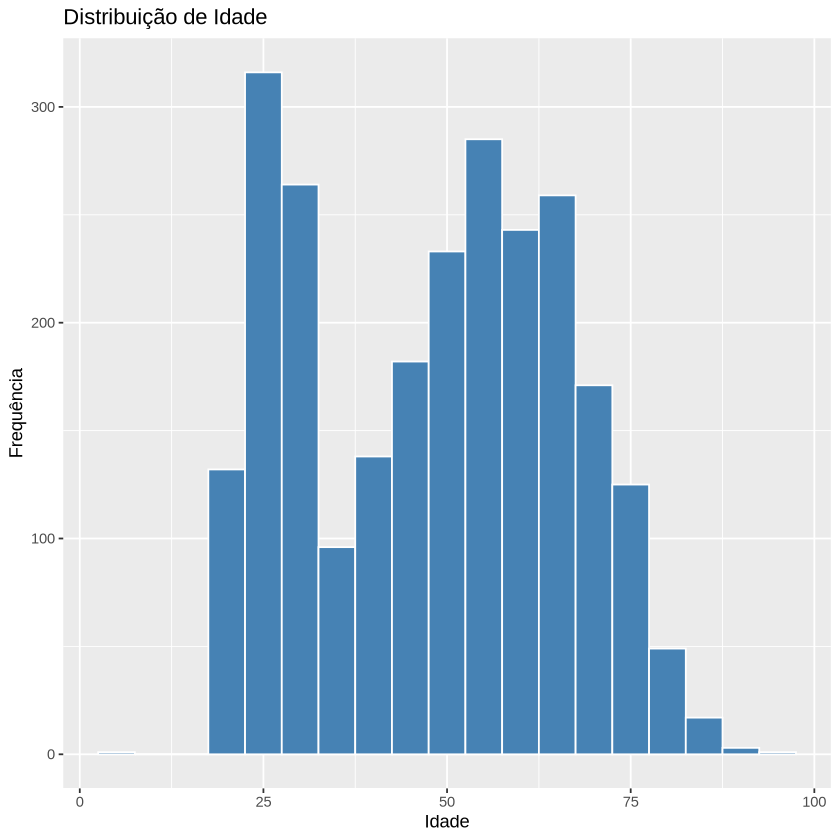

In [32]:
ggplot(predicao, aes(x = idade)) +
  geom_histogram(binwidth = 5, fill = "steelblue", color = "white") +
  labs(title = "Distribuição de Idade", x = "Idade", y = "Frequência")

In [33]:
pasta_imagens = "/home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_analise_cpod"

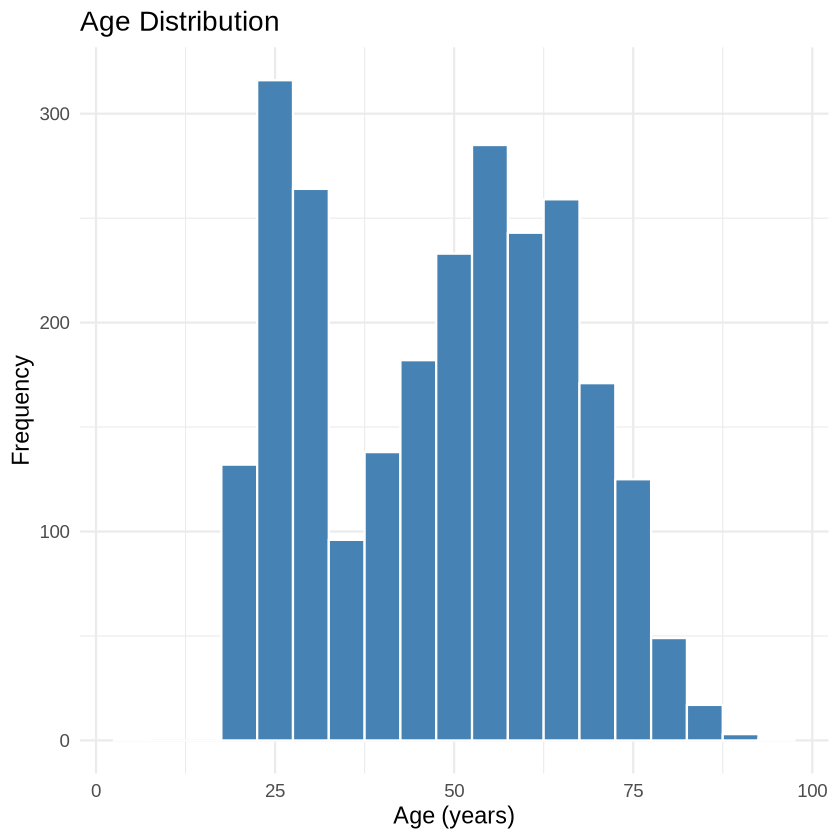

In [34]:
# Cria o gráfico
p_age <- ggplot(predicao, aes(x = idade)) +
  geom_histogram(binwidth = 5, fill = "steelblue", color = "white") +
  labs(
    title = "Age Distribution",
    x = "Age (years)",
    y = "Frequency"
  ) +
  theme_minimal(base_size = 14)

# Exibe o gráfico
print(p_age)

# Salva automaticamente na pasta especificada
ggsave(
  filename = file.path(pasta_imagens, "age_distribution.png"),
  plot = p_age,
  width = 6,
  height = 4,
  dpi = 300
)

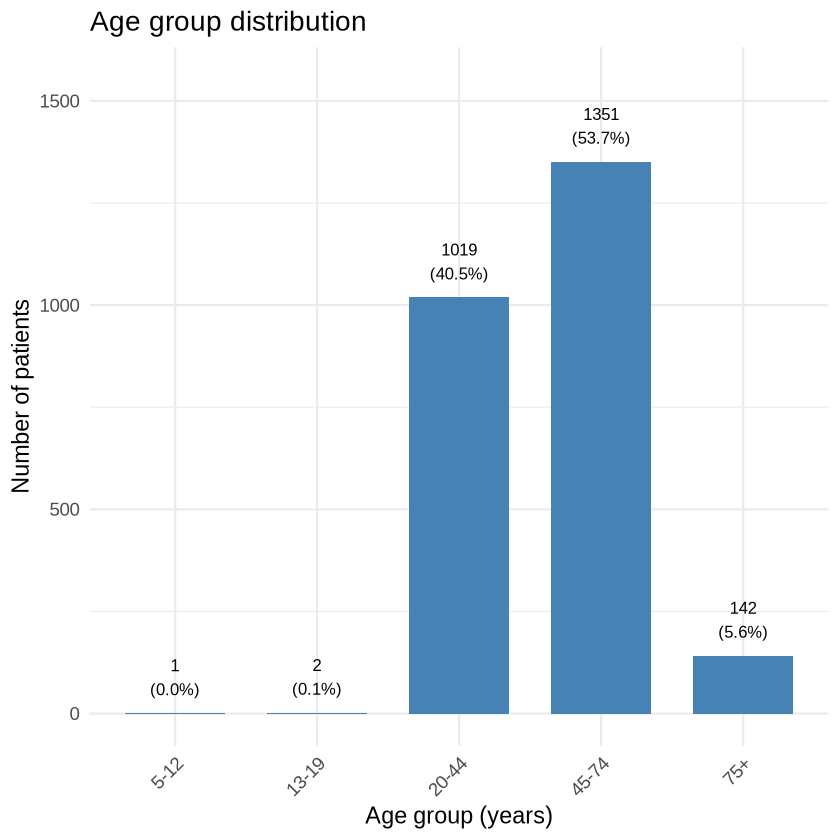

In [35]:
plot_faixa_etaria <- function(df, titulo = "Age group distribution") {
  
  ordem <- c("5-12", "13-19", "20-44", "45-74", "75+")
  
  dados <- df %>%
    count(faixa_etaria) %>%
    mutate(
      faixa_etaria = factor(faixa_etaria, levels = ordem, ordered = TRUE),
      prop = n / sum(n)
    )
  
  max_y <- max(dados$n) * 1.15   # calcula o limite superior fora do ggplot
  
  ggplot(dados, aes(x = faixa_etaria, y = n)) +
    geom_col(fill = "steelblue", width = 0.7) +
    geom_text(aes(label = paste0(n, "\n(", percent(prop, accuracy = 0.1), ")")),
              vjust = -0.5, size = 3.5) +
    expand_limits(y = max_y) +
    labs(
      title = titulo,
      x = "Age group (years)",
      y = "Number of patients"
    ) +
    theme_minimal(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

# Exemplo de uso:
plot_faixa_etaria(gabarito)

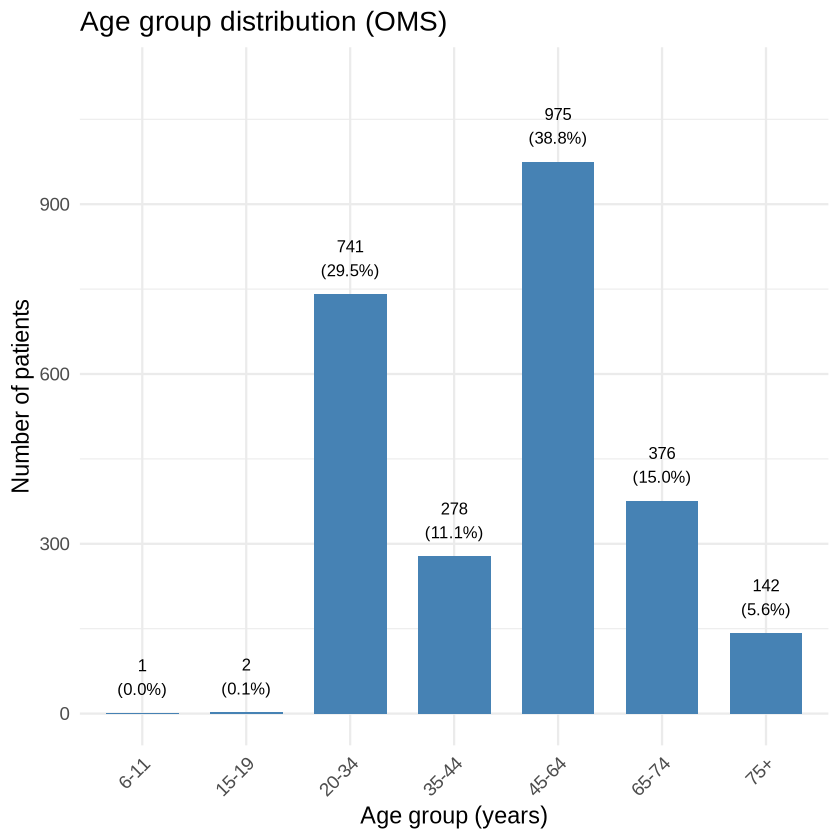

In [36]:
plot_faixa_etaria_oms <- function(df, titulo = "Age group distribution (OMS)") {
  
  ordem <- c("5", "6-11", "12", "13-14", "15-19",
                    "20-34", "35-44", "45-64", "65-74", "75+")
  
  dados <- df %>%
    count(faixa_etaria_oms) %>%
    mutate(
      faixa_etaria_oms = factor(faixa_etaria_oms, levels = ordem, ordered = TRUE),
      prop = n / sum(n)
    )
  
  max_y <- max(dados$n) * 1.15   # calcula o limite superior fora do ggplot
  
  ggplot(dados, aes(x = faixa_etaria_oms, y = n)) +
    geom_col(fill = "steelblue", width = 0.7) +
    geom_text(aes(label = paste0(n, "\n(", percent(prop, accuracy = 0.1), ")")),
              vjust = -0.5, size = 3.5) +
    expand_limits(y = max_y) +
    labs(
      title = titulo,
      x = "Age group (years)",
      y = "Number of patients"
    ) +
    theme_minimal(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

# Exemplo de uso:
plot_faixa_etaria_oms(gabarito)

<!-- 12 anos
15-19 anos
35-44 
65-74 -->

In [37]:
plot_faixa_etaria_oms <- function(df,
                                  titulo = "Age Group Distribution (WHO)",
                                  save_path = NULL,   # caminho completo do arquivo (pasta + nome)
                                  width = 7, height = 5, dpi = 300) {
  library(dplyr)
  library(ggplot2)
  library(scales)
  
  ordem <- c("5", "6-11", "12", "13-14", "15-19",
             "20-34", "35-44", "45-64", "65-74", "75+")
  
  # faixas que devem ser destacadas
  faixas_destaque <- c("12", "15-19", "35-44", "65-74")
  
  dados <- df %>%
    count(faixa_etaria_oms) %>%
    mutate(
      faixa_etaria_oms = factor(faixa_etaria_oms, levels = ordem, ordered = TRUE),
      prop = n / sum(n),
      grupo_cor = ifelse(faixa_etaria_oms %in% faixas_destaque, "destaque", "normal")
    )
  
  max_y <- max(dados$n) * 1.15
  
  p <- ggplot(dados, aes(x = faixa_etaria_oms, y = n, fill = grupo_cor)) +
    geom_col(width = 0.7) +
    geom_text(aes(label = paste0(n, "\n(", percent(prop, accuracy = 0.1), ")")),
              vjust = -0.5, size = 3.5) +
    scale_fill_manual(
      values = c(
        "destaque" = "#1B3A6F",   # azul mais escuro
        "normal"   = "steelblue"  # azul padrão
      ),
      guide = "none"
    ) +
    expand_limits(y = max_y) +
    labs(
      title = titulo,
      x = "Age group (years)",
      y = "Number of patients"
    ) +
    theme_minimal(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
  
  # salvar, se for pedido
  if (!is.null(save_path)) {
    ggsave(filename = save_path, plot = p, width = width, height = height, dpi = dpi)
    message("Plot saved to: ", save_path)
  }
  
  return(p)
}

Plot saved to: /home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_analise_cpod/age_group_distribution_oms.png



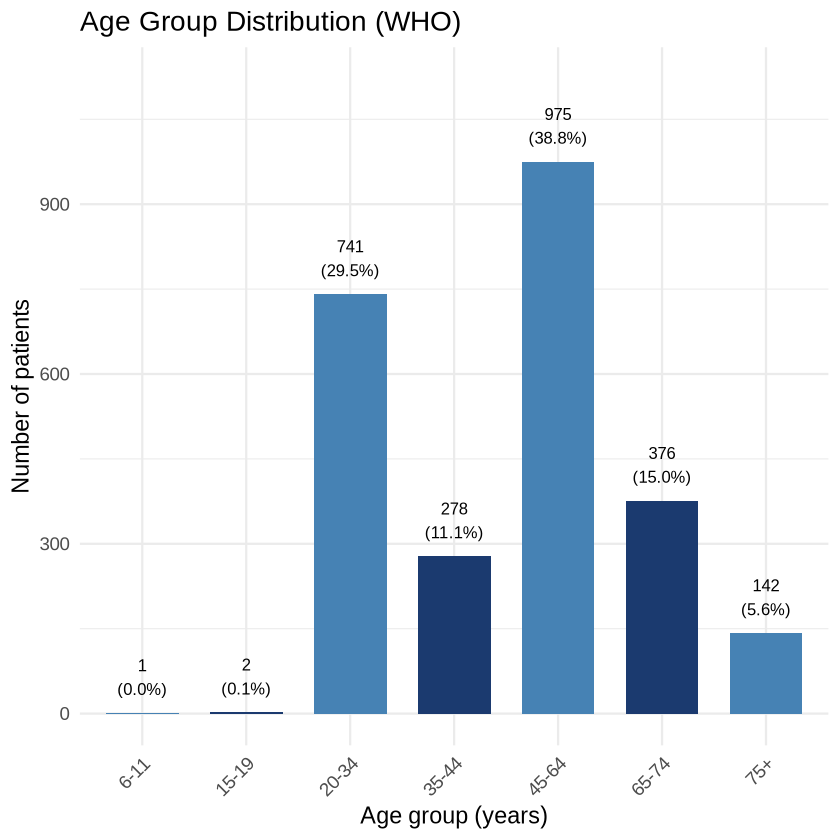

In [38]:
plot_faixa_etaria_oms(
  gabarito,
  save_path = file.path(pasta_imagens, "age_group_distribution_oms.png")
)

#### Sexo

In [39]:
# Distribuição por sexo
resumo_sexo <- predicao %>%
  count(sexo) %>%
  mutate(proporcao = round(100 * n / sum(n), 2))
print("Distribuição por sexo:")
print(resumo_sexo)

[1] "Distribuição por sexo:"
# A tibble: 2 × 3
  sexo          n proporcao
  <chr>     <int>     <dbl>
1 feminino   1519      60.4
2 masculino   996      39.6


In [40]:
library(dplyr)
library(ggplot2)
library(scales)

# Preparar os dados agregados
dados_sexo <- predicao %>%
  count(sexo) %>%
  mutate(prop = n / sum(n))

# Criar o gráfico
p <- ggplot(dados_sexo, aes(x = sexo, y = n, fill = sexo)) +
  geom_col(alpha = 0.9) +
  geom_text(
    aes(label = paste0(n, "\n(", percent(prop, accuracy = 0.1), ")")),
    vjust = -0.3,
    size = 4
  ) +
  expand_limits(y = max(dados_sexo$n) * 1.15) +
  labs(
    title = "Sex Distribution",
    x = "Sex",
    y = "Count"
  ) +6
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "none"
  )

# Exibe o gráfico
print(p)

# Salvar
ggsave(
  filename = file.path(pasta_imagens, "sex_distribution.png"),
  plot = p,
  width = 6,
  height = 4,
  dpi = 300
)

message("✓ Image saved to: ", file.path(pasta_imagens, "sex_distribution.png"))

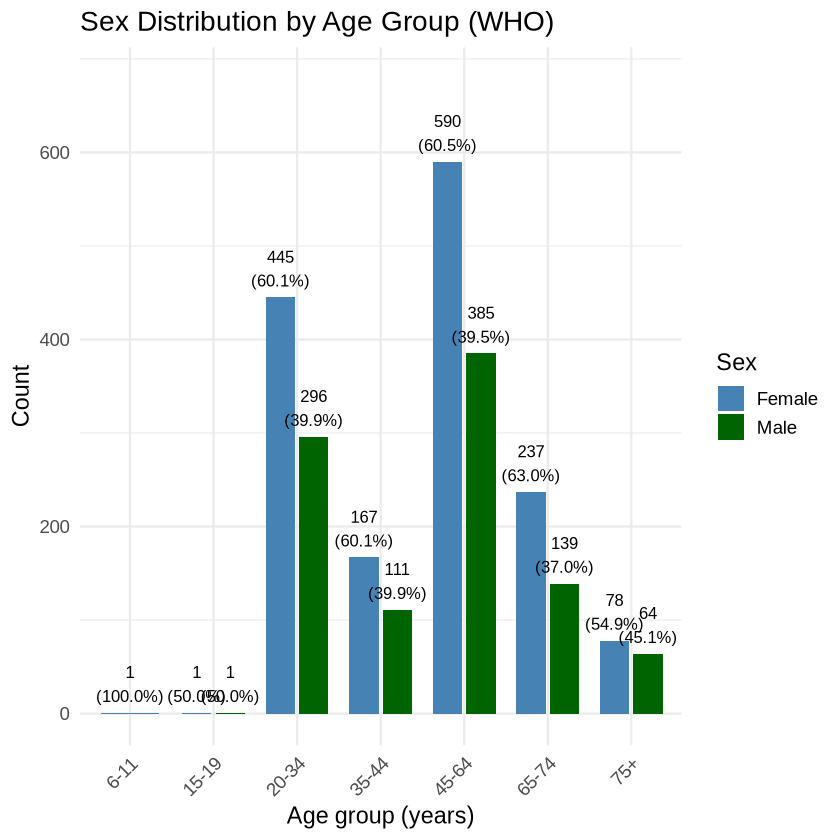

In [41]:
library(dplyr)
library(ggplot2)
library(scales)

ordem_oms <- c("5", "6-11", "12", "13-14", "15-19",
               "20-34", "35-44", "45-64", "65-74", "75+")

dados_sexo_oms <- predicao %>%
  count(faixa_etaria_oms, sexo) %>%
  group_by(faixa_etaria_oms) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(
    faixa_etaria_oms = factor(faixa_etaria_oms,
                              levels = ordem_oms,
                              ordered = TRUE)
  )

p_oms <- ggplot(dados_sexo_oms,
                aes(x = faixa_etaria_oms, y = n, fill = sexo)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  geom_text(
    aes(label = paste0(n, "\n(", percent(prop, accuracy = 0.1), ")")),
    position = position_dodge(width = 0.8),
    vjust = -0.3,
    size = 3.5
  ) +
  expand_limits(y = max(dados_sexo_oms$n) * 1.15) +
  labs(
    title = "Sex Distribution by Age Group (WHO)",
    x = "Age group (years)",
    y = "Count"
  ) +
  scale_fill_manual(
    name   = "Sex",  # título da legenda
    values = c("feminino" = "steelblue", "masculino" = "darkgreen"),
    labels = c("feminino" = "Female",  "masculino" = "Male")
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

print(p_oms)

ggsave(
  filename = file.path(pasta_imagens, "sex_distribution_by_age_oms.png"),
  plot = p_oms,
  width = 7,
  height = 5,
  dpi = 300
)


#### Clínica

In [42]:
# Distribuição por origem
resumo_origem <- predicao %>%
  count(origem) %>%
  mutate(proporcao = round(100 * n / sum(n), 2))
print("Distribuição por origem:")
print(resumo_origem)

[1] "Distribuição por origem:"
# A tibble: 15 × 3
   origem           n proporcao
   <chr>        <int>     <dbl>
 1 Alphaville      55      2.19
 2 Ibirapuera      86      3.42
 3 Ipiranga        72      2.86
 4 Jardins        269     10.7 
 5 Jd. America    190      7.55
 6 Lapa           162      6.44
 7 Mooca           95      3.78
 8 Morumbi         56      2.23
 9 Osasco          55      2.19
10 Penha           66      2.62
11 Santana        446     17.7 
12 Santo Amaro    287     11.4 
13 Tatuape        402     16.0 
14 Tucuruvi         1      0.04
15 Vila Mariana   273     10.8 


✓ Image saved to: /home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_analise_cpod/exams_by_clinic.png



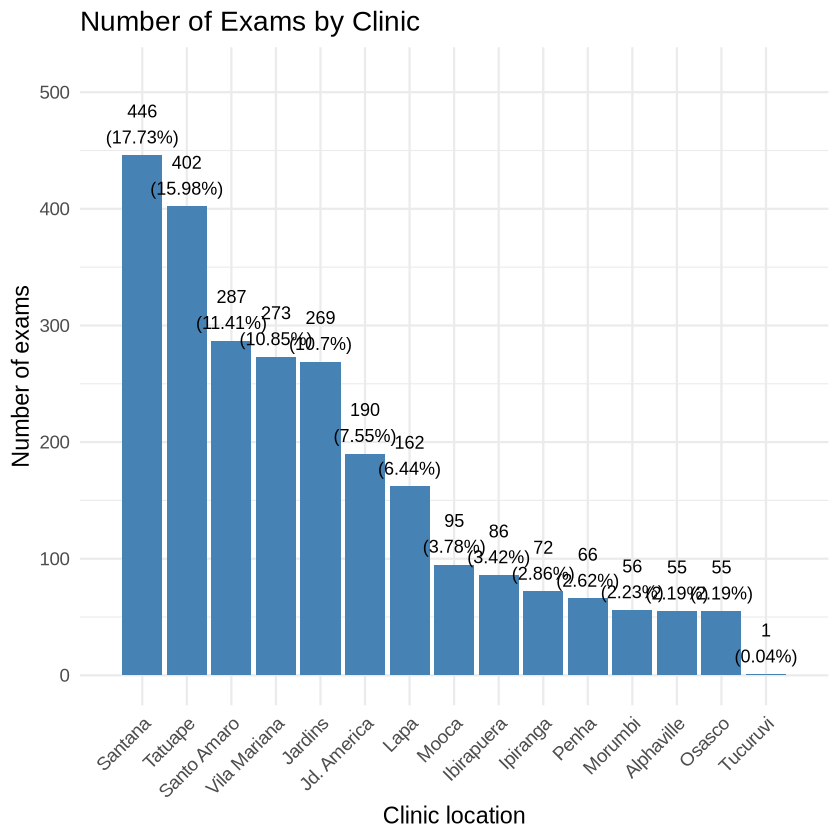

In [43]:
# Criar o gráfico
p_origem <- ggplot(resumo_origem, aes(x = reorder(origem, -n), y = n)) +
  geom_col(fill = "steelblue") +
  geom_text(
    aes(label = paste0(n, "\n(", proporcao, "%)")),
    vjust = -0.3,
    size = 3.8
  ) +
  expand_limits(y = max(resumo_origem$n) * 1.15) +  
  scale_x_discrete(expand = expansion(mult = c(0.1, 0.1))) +
  labs(
    title = "Number of Exams by Clinic",
    x = "Clinic location",
    y = "Number of exams"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

# Exibir o gráfico
print(p_origem)

# Salvar no diretório especificado
ggsave(
  filename = file.path(pasta_imagens, "exams_by_clinic.png"),
  plot = p_origem,
  width = 7,
  height = 4.5,
  dpi = 300
)

message("✓ Image saved to: ", file.path(pasta_imagens, "exams_by_clinic.png"))


In [44]:
plot_region_counts <- function(df, title = "Exams by macro-region (São Paulo)") {
  # Garantir fator com níveis esperados (opcional)
  df <- df %>% mutate(
    regiao_sp = forcats::fct_explicit_na(regiao_sp, na_level = "Others")
  )
  
  dados <- df %>%
    count(regiao_sp, name = "n") %>%
    mutate(prop = n / sum(n)) %>%
    arrange(desc(n)) %>%
    mutate(regiao_sp = factor(regiao_sp, levels = regiao_sp))  # ordenar pelas contagens

  max_y <- max(dados$n) * 1.15

  ggplot(dados, aes(x = regiao_sp, y = n)) +
    geom_col(fill = "steelblue") +
    geom_text(aes(label = paste0(n, "\n(", percent(prop, accuracy = 0.1), ")")),
              vjust = -0.4, size = 3.6, lineheight = 0.95) +
    expand_limits(y = max_y) +
    labs(
      title = title,
      x = "Macro-region",
      y = "Number of exams"
    ) +
    theme_minimal(base_size = 13) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1)
    )
}

# Exemplo de uso:
# plot_region_counts(gabarito, title = "Exams by macro-region (São Paulo)")

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `regiao_sp = forcats::fct_explicit_na(regiao_sp, na_level =
  "Others")`.
Caused by warning:
! `fct_explicit_na()` was deprecated in forcats 1.0.0.
ℹ Please use `fct_na_value_to_level()` instead.”
✅ Figure saved to: /var/home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_analise_cpod/grafico_regioes.png



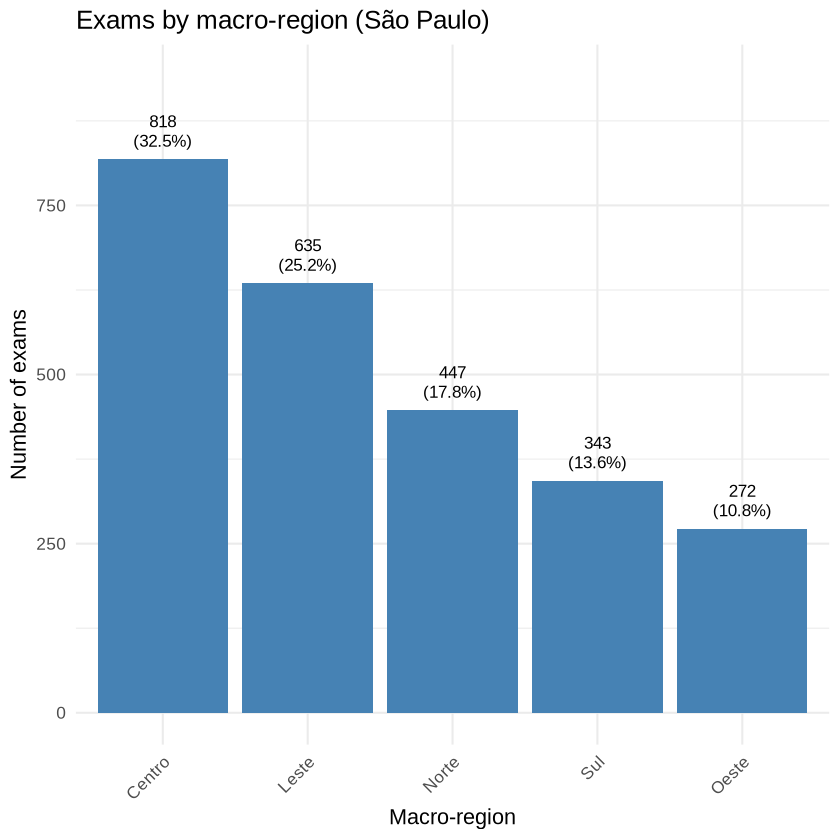

In [45]:
plot_region_counts <- function(df, 
                               title = "Exams by macro-region (São Paulo)",
                               save_path = NULL,      # novo parâmetro opcional
                               width = 6, height = 4, dpi = 300) {
  
  # Garantir que a variável exista
  df <- df %>% mutate(
    regiao_sp = forcats::fct_explicit_na(regiao_sp, na_level = "Others")
  )
  
  # Calcular proporções e ordenar
  dados <- df %>%
    count(regiao_sp, name = "n") %>%
    mutate(prop = n / sum(n)) %>%
    arrange(desc(n)) %>%
    mutate(regiao_sp = factor(regiao_sp, levels = regiao_sp))
  
  max_y <- max(dados$n) * 1.15
  
  # Criar o gráfico
  p <- ggplot(dados, aes(x = regiao_sp, y = n)) +
    geom_col(fill = "steelblue") +
    geom_text(aes(label = paste0(n, "\n(", percent(prop, accuracy = 0.1), ")")),
              vjust = -0.4, size = 3.6, lineheight = 0.95) +
    expand_limits(y = max_y) +
    labs(
      title = title,
      x = "Macro-region",
      y = "Number of exams"
    ) +
    theme_minimal(base_size = 13) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
  
  # Exibe o gráfico normalmente
  print(p)
  
  # Salva se o caminho for informado
  if (!is.null(save_path)) {
    ggsave(filename = save_path, plot = p, width = width, height = height, dpi = dpi)
    message("✅ Figure saved to: ", normalizePath(save_path))
  }
  
  invisible(p)
}

plot_region_counts(
  gabarito,
  save_path = "/var/home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_analise_cpod/grafico_regioes.png"
)

#### Clínica e sexo

In [46]:
# Combinação de origem e sexo
resumo_origem_sexo <- predicao %>%
  count(origem, sexo) %>%
  group_by(origem) %>%
  mutate(proporcao = round(100 * n / sum(n), 2))
print("Distribuição cruzada por origem e sexo:")
print(resumo_origem_sexo, n=Inf)

[1] "Distribuição cruzada por origem e sexo:"
# A tibble: 29 × 4
# Groups:   origem [15]
   origem       sexo          n proporcao
   <chr>        <chr>     <int>     <dbl>
 1 Alphaville   feminino     35      63.6
 2 Alphaville   masculino    20      36.4
 3 Ibirapuera   feminino     60      69.8
 4 Ibirapuera   masculino    26      30.2
 5 Ipiranga     feminino     39      54.2
 6 Ipiranga     masculino    33      45.8
 7 Jardins      feminino    146      54.3
 8 Jardins      masculino   123      45.7
 9 Jd. America  feminino    109      57.4
10 Jd. America  masculino    81      42.6
11 Lapa         feminino     92      56.8
12 Lapa         masculino    70      43.2
13 Mooca        feminino     64      67.4
14 Mooca        masculino    31      32.6
15 Morumbi      feminino     33      58.9
16 Morumbi      masculino    23      41.1
17 Osasco       feminino     37      67.3
18 Osasco       masculino    18      32.7
19 Penha        feminino     45      68.2
20 Penha        masculino    

✓ Image saved to: /home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_analise_cpod/sexo_por_origem.png



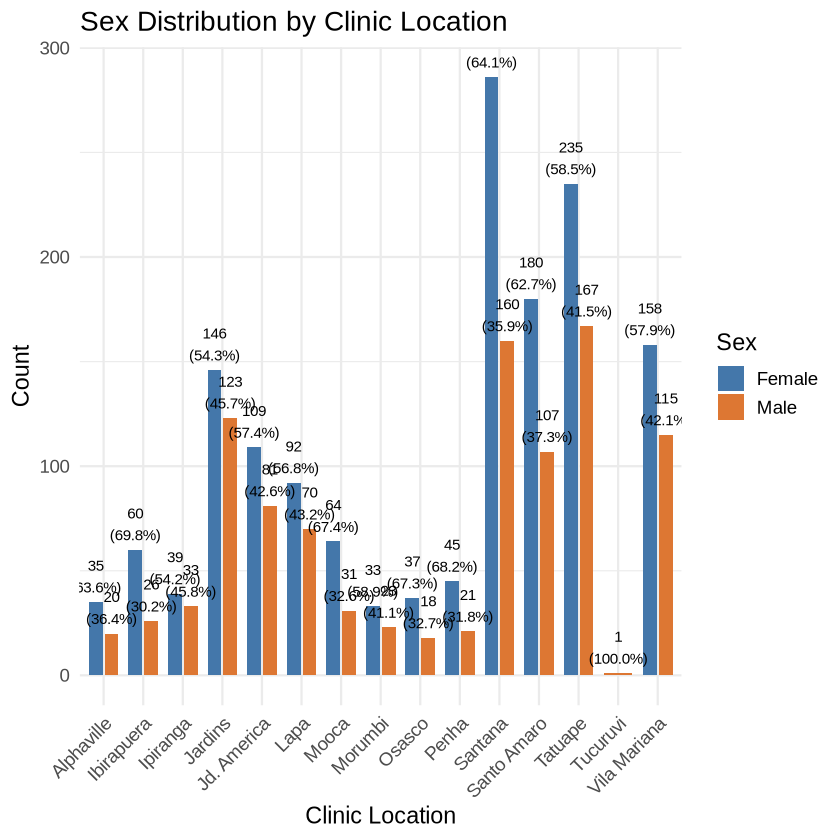

In [47]:
library(dplyr)
library(ggplot2)
library(scales)

# Preparar os dados
resumo_origem_sexo <- predicao %>%
  count(origem, sexo) %>%
  group_by(origem) %>%
  mutate(proporcao = n / sum(n)) %>%
  ungroup()

# Criar o gráfico
g_origem_sexo <- ggplot(resumo_origem_sexo,
                        aes(x = origem, y = n, fill = sexo)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  geom_text(
    aes(label = paste0(n, "\n(", percent(proporcao, accuracy = 0.1), ")")),
    position = position_dodge(width = 0.8),
    vjust = -0.3,
    size = 3.2
  ) +
  labs(
    title = "Sex Distribution by Clinic Location",
    x = "Clinic Location",
    y = "Count",
    fill = "Sex"
  ) +
  scale_fill_manual(
    values = c("feminino" = "#4477AA", "masculino" = "#DD7733"),
    labels = c("feminino" = "Female", "masculino" = "Male")
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

# Exibir o gráfico
print(g_origem_sexo)

# Salvar o gráfico
ggsave(
  filename = file.path(pasta_imagens, "sexo_por_origem.png"),
  plot = g_origem_sexo,
  width = 8,
  height = 5,
  dpi = 300
)

message("✓ Image saved to: ", file.path(pasta_imagens, "sexo_por_origem.png"))


### Clinica e idade

✓ Image saved to: /home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_analise_cpod/clinic_location_by_age_who.png



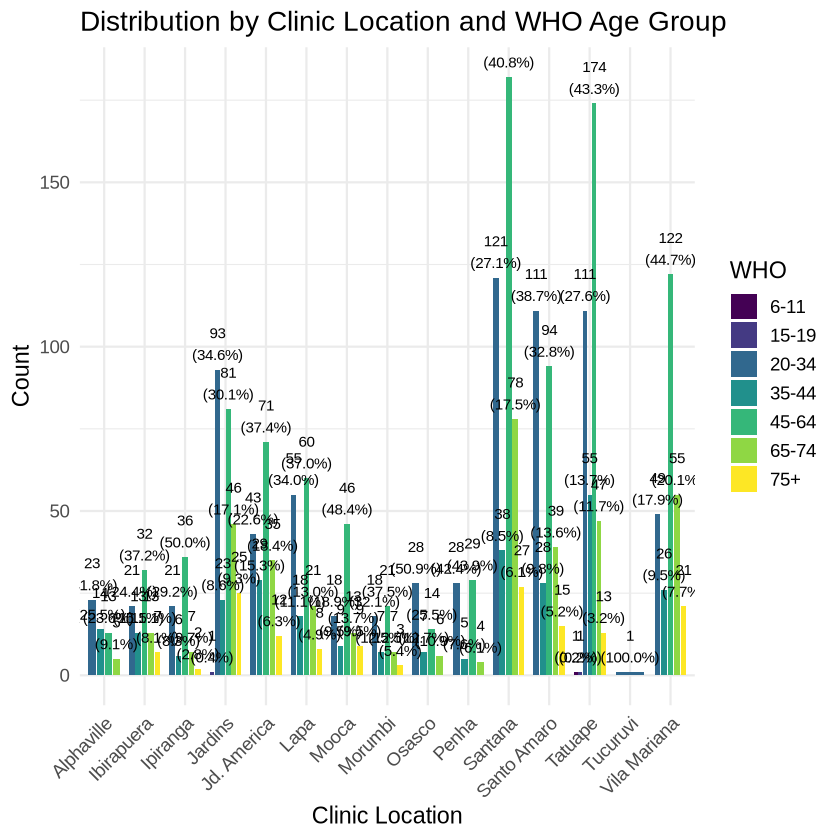

In [48]:
library(dplyr)
library(ggplot2)
library(scales)

# Ordem das faixas OMS
ordem_oms <- c("5", "6-11", "12", "13-14", "15-19",
               "20-34", "35-44", "45-64", "65-74", "75+")

# Preparar os dados: origem × faixa etária OMS
resumo_origem_oms <- predicao %>%
  count(origem, faixa_etaria_oms) %>%
  group_by(origem) %>%
  mutate(proporcao = n / sum(n)) %>%
  ungroup() %>%
  mutate(
    faixa_etaria_oms = factor(faixa_etaria_oms,
                              levels = ordem_oms,
                              ordered = TRUE)
  )

# Criar o gráfico
g_origem_oms <- ggplot(resumo_origem_oms,
                       aes(x = origem, y = n, fill = faixa_etaria_oms)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  geom_text(
    aes(label = paste0(n, "\n(", percent(proporcao, accuracy = 0.1), ")")),
    position = position_dodge(width = 0.8),
    vjust = -0.3,
    size = 3.2
  ) +
  labs(
    title = "Distribution by Clinic Location and WHO Age Group",
    x = "Clinic Location",
    y = "Count",
    fill = "WHO"   # legenda da faixa OMS
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

# Mostrar o gráfico
print(g_origem_oms)

# Salvar o gráfico
ggsave(
  filename = file.path(pasta_imagens, "clinic_location_by_age_who.png"),
  plot = g_origem_oms,
  width = 10,
  height = 6,
  dpi = 300
)

message("✓ Image saved to: ",
        file.path(pasta_imagens, "clinic_location_by_age_who.png"))


In [49]:
tabela_origem_oms <- predicao %>%
  count(origem, faixa_etaria_oms) %>%
  group_by(origem) %>%
  mutate(
    proporcao = round(100 * n / sum(n), 2)
  ) %>%
  ungroup() %>%
  arrange(origem, faixa_etaria_oms)

print(tabela_origem_oms, n = Inf)


# A tibble: 71 × 4
   origem       faixa_etaria_oms     n proporcao
   <chr>        <ord>            <int>     <dbl>
 1 Alphaville   20-34               23     41.8 
 2 Alphaville   35-44               14     25.4 
 3 Alphaville   45-64               13     23.6 
 4 Alphaville   65-74                5      9.09
 5 Ibirapuera   20-34               21     24.4 
 6 Ibirapuera   35-44               13     15.1 
 7 Ibirapuera   45-64               32     37.2 
 8 Ibirapuera   65-74               13     15.1 
 9 Ibirapuera   75+                  7      8.14
10 Ipiranga     20-34               21     29.2 
11 Ipiranga     35-44                6      8.33
12 Ipiranga     45-64               36     50   
13 Ipiranga     65-74                7      9.72
14 Ipiranga     75+                  2      2.78
15 Jardins      15-19                1      0.37
16 Jardins      20-34               93     34.6 
17 Jardins      35-44               23      8.55
18 Jardins      45-64               81     30.1 
1

In [51]:
library(dplyr)
library(knitr)

tabela_idade_clinica <- predicao %>%
  group_by(origem) %>%
  summarise(
    n = n(),
    mean_age = round(mean(idade, na.rm = TRUE), 2),
    median_age = round(median(idade, na.rm = TRUE), 2),
    sd_age = round(sd(idade, na.rm = TRUE), 2),
    min_age = min(idade, na.rm = TRUE),
    max_age = max(idade, na.rm = TRUE)
  ) %>%
  arrange(origem)

latex_table <- kable(
  tabela_idade_clinica,
  format = "latex",
  booktabs = TRUE,
  caption = "Age distribution by clinic location",
  label = "tab:age_by_clinic"
)

cat(latex_table)

\begin{table}

\caption{\label{tab:tab:age_by_clinic}Age distribution by clinic location}
\centering
\begin{tabular}[t]{lrrrrrr}
\toprule
origem & n & mean\_age & median\_age & sd\_age & min\_age & max\_age\\
\midrule
Alphaville & 55 & 40.42 & 39.0 & 14.60 & 20 & 68\\
Ibirapuera & 86 & 49.06 & 49.0 & 17.49 & 20 & 84\\
Ipiranga & 72 & 47.43 & 50.5 & 16.08 & 21 & 79\\
Jardins & 269 & 48.45 & 50.0 & 19.12 & 19 & 93\\
Jd. America & 190 & 50.32 & 51.5 & 16.72 & 20 & 92\\
\addlinespace
Lapa & 162 & 46.50 & 48.0 & 17.25 & 20 & 85\\
Mooca & 95 & 51.88 & 52.0 & 16.17 & 20 & 83\\
Morumbi & 56 & 46.73 & 47.5 & 17.34 & 20 & 84\\
Osasco & 55 & 39.18 & 30.0 & 15.42 & 20 & 70\\
Penha & 66 & 41.50 & 44.5 & 15.51 & 21 & 69\\
\addlinespace
Santana & 446 & 49.81 & 53.0 & 17.41 & 20 & 90\\
Santo Amaro & 287 & 45.27 & 45.0 & 18.07 & 20 & 83\\
Tatuape & 402 & 47.28 & 50.0 & 16.43 & 7 & 82\\
Tucuruvi & 1 & 28.00 & 28.0 & NA & 28 & 28\\
Vila Mariana & 273 & 53.54 & 57.0 & 16.60 & 20 & 86\\
\bottomrule
\end{ta

### Desempenho do modelo de numeração por dente e dentes ausentes

In [52]:
contar_erros_por_exame <- function(gabarito, predicao) {
  
  # Garante alinhamento por cd_exame
  stopifnot(all(gabarito$cd_exame == predicao$cd_exame))
  
  # Seleciona colunas de dentes (apenas ausente_)
  cols <- intersect(names(gabarito), names(predicao))
  cols_dentes <- grep("^ausente_\\d{2}$", cols, value = TRUE)
  
  if (length(cols_dentes) == 0) stop("Nenhuma coluna 'ausente_XX' encontrada.")
  
  # Converte para numérico
  gabarito[cols_dentes] <- lapply(gabarito[cols_dentes], as.numeric)
  predicao[cols_dentes] <- lapply(predicao[cols_dentes], as.numeric)
  
  # Matriz de erros: 1 se diferente, 0 se igual
  erros <- (gabarito[cols_dentes] != predicao[cols_dentes]) * 1
  
  # Soma total de erros, ausentes no gabarito e ausentes preditos
  erros_por_exame <- tibble(
    cd_exame = gabarito$cd_exame,
    origem   = gabarito$origem,
    idade    = gabarito$idade,
    sexo     = gabarito$sexo,
    total_erros       = rowSums(erros, na.rm = TRUE),
    ausentes_gabarito = rowSums(gabarito[cols_dentes], na.rm = TRUE),
    ausentes_predicao = rowSums(predicao[cols_dentes], na.rm = TRUE)
  ) %>%
    mutate(diferenca = ausentes_predicao - ausentes_gabarito) %>%
    arrange(desc(total_erros))
  
  print("Top exames com mais erros (ausentes):")
  print(head(erros_por_exame, 20))
  
  return(erros_por_exame)
}


erros_exames <- contar_erros_por_exame(gabarito, predicao)

write.csv(erros_exames, "/home/aninha/Desktop/Doutorado/Dados/odontograma_erros.csv",row.names=FALSE)

[1] "Top exames com mais erros (ausentes):"
# A tibble: 20 × 8
   cd_exame   origem idade sexo  total_erros ausentes_gabarito ausentes_predicao
   <chr>      <chr>  <dbl> <chr>       <dbl>             <dbl>             <dbl>
 1 san.313482 Santa…    70 masc…          29                 0                29
 2 moo.041175 Mooca     56 femi…          27                 5                32
 3 tat.340116 Tatua…    48 femi…          27                 5                32
 4 tat.352474 Tatua…    27 masc…          27                 0                27
 5 lap.293986 Lapa      60 femi…          26                 6                32
 6 san.283907 Santa…    60 femi…          25                 7                32
 7 sto.233044 Santo…    64 femi…          25                 7                32
 8 tat.344257 Tatua…    64 masc…          25                 7                32
 9 vma.227692 Vila …    68 femi…          25                 7                32
10 san.309501 Santa…    67 femi…          24  

In [53]:
resultado_ausente  <- metrics_by_tooth(gabarito, predicao, prefix = "ausente")
resultado_ausente

target,coluna,dente,n,tp,fp,tn,fn,precision,recall,f1,accuracy,prevalence_gt,mean_count_gt,mean_count_pred
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ausente,ausente_11,11,2515,114,88,2157,156,0.5643564,0.4222222,0.4830508,0.9029821,0.10735586,0.10735586,0.08031809
ausente,ausente_12,12,2515,96,104,2110,205,0.4800000,0.3189369,0.3832335,0.8771372,0.11968191,0.11968191,0.07952286
ausente,ausente_13,13,2515,58,128,2244,85,0.3118280,0.4055944,0.3525836,0.9153082,0.05685885,0.05685885,0.07395626
ausente,ausente_14,14,2515,172,155,1792,396,0.5259939,0.3028169,0.3843575,0.7809145,0.22584493,0.22584493,0.13001988
ausente,ausente_15,15,2515,257,219,1700,339,0.5399160,0.4312081,0.4794776,0.7781312,0.23697813,0.23697813,0.18926441
ausente,ausente_16,16,2515,379,218,1659,259,0.6348409,0.5940439,0.6137652,0.8103380,0.25367793,0.25367793,0.23737575
ausente,ausente_17,17,2515,353,185,1826,151,0.6561338,0.7003968,0.6775432,0.8664016,0.20039761,0.20039761,0.21391650
ausente,ausente_18,18,2515,1402,167,835,111,0.8935628,0.9266358,0.9097988,0.8894632,0.60159046,0.60159046,0.62385686
ausente,ausente_21,21,2515,123,93,2138,161,0.5694444,0.4330986,0.4920000,0.8990060,0.11292247,0.11292247,0.08588469


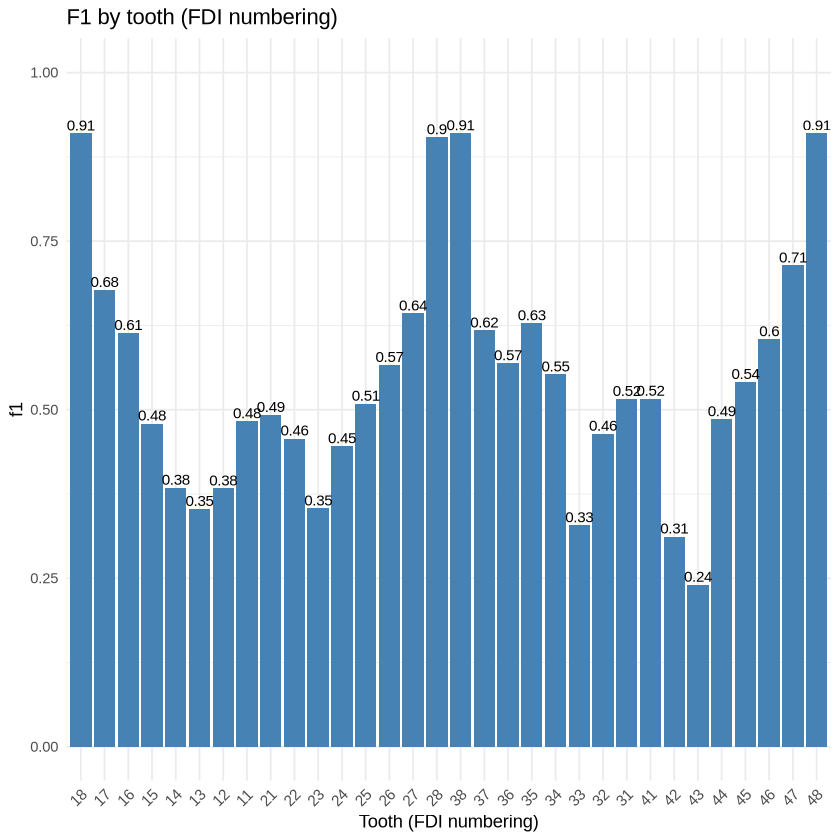

In [54]:
# Para F1-score de dentes ausentes
plot_metric_by_tooth(resultado_ausente, metric = "f1", color = "steelblue")

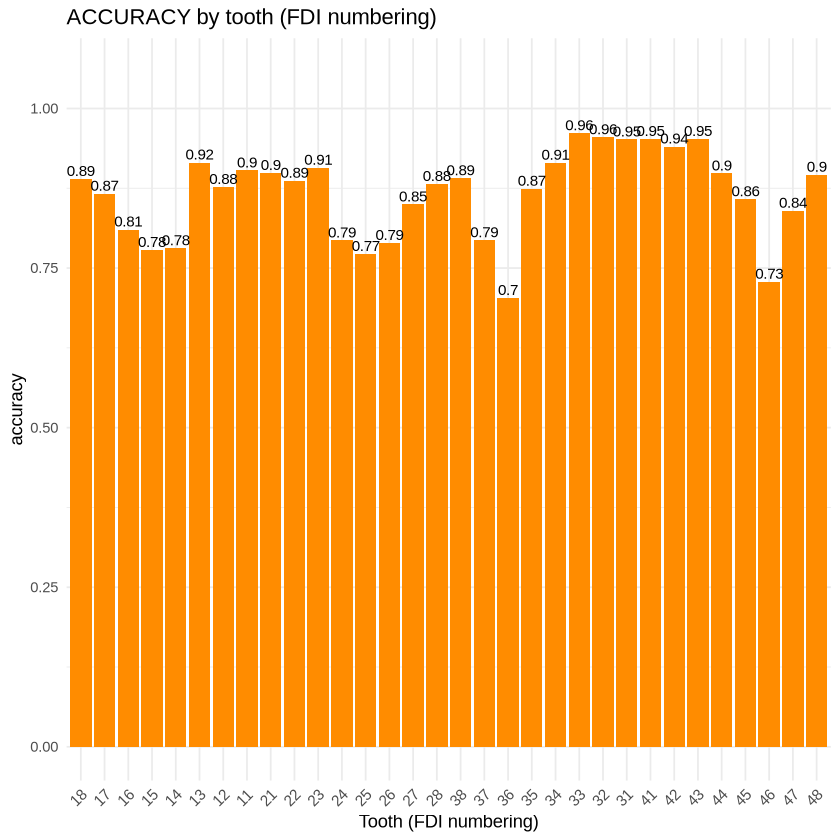

In [55]:
# Para acurácia de dentes ausentes
plot_metric_by_tooth(resultado_ausente, metric = "accuracy", color = "darkorange")

In [56]:
resumo_ausente <- aggregate_macro_micro(resultado_ausente)

[1] "Resumo global (macro e micro):"
# A tibble: 2 × 6
  agg   precision recall    f1 accuracy
  <chr>     <dbl>  <dbl> <dbl>    <dbl>
1 macro     0.600  0.532 0.549    0.866
2 micro     0.734  0.630 0.678    0.866
  description                                                                  
  <chr>                                                                        
1 Average of metrics across all teeth (each tooth has equal weight)            
2 Global metrics considering all teeth together (weighted by number of samples)


#### Considerando somente a quantidade absoluta de dentes ausentes por indivíduo

In [57]:
resultado_ausente_count <- compute_counts_by_exam(gabarito, predicao, prefix = "ausente")
resultado_ausente_count

cd_exame,count_gt,count_pred,prefix,diff,abs_diff,correct_count
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<int>
alp.026080,0,0,ausente,0,0,1
alp.026233,1,1,ausente,0,0,1
alp.026520,13,10,ausente,-3,3,0
alp.026854,0,0,ausente,0,0,1
alp.026933,1,10,ausente,9,9,0
alp.027497,12,9,ausente,-3,3,0
alp.027622,1,0,ausente,-1,1,0
alp.027806,3,3,ausente,0,0,1
alp.027880,5,4,ausente,-1,1,0


In [58]:
summarize_count_metrics(resultado_ausente_count)

prefix,n_exames,exact_match_rate,mae,rmse,bias
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
ausente,2515,0.2548708,2.872763,4.732738,-1.015109


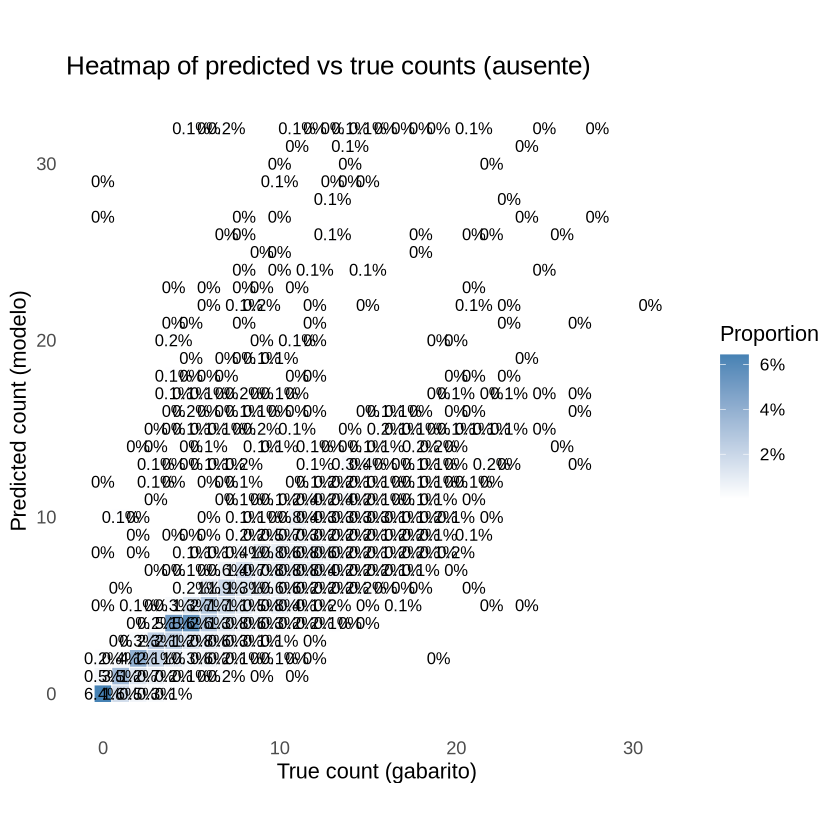

In [59]:
contingency_table_counts(resultado_ausente_count, normalize = TRUE)

In [ ]:
# (Opcional) salvar resultados
# write_csv(contagens, "avaliacao_contagem_por_exame.csv")
# write_csv(metricas_count, "metricas_globais_contagem.csv")
# write_csv(tab_contagem, "tabela_contingencia_contagens.csv")
# write_csv(acc_por_alvo, "exatidao_por_alvo_contagens.csv")

### Desempenho do modelo de cáries

In [60]:
resultado_carie  <- metrics_by_tooth(gabarito, predicao, prefix = "carie")
resultado_carie

target,coluna,dente,n,tp,fp,tn,fn,precision,recall,f1,accuracy,prevalence_gt,mean_count_gt,mean_count_pred
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
carie,carie_11,11,2515,0,0,2357,158,NA,0.000000000,NA,0.9371769,0.06282306,0.06282306,0.0000000000
carie,carie_12,12,2515,0,0,2318,197,NA,0.000000000,NA,0.9216700,0.07833002,0.07833002,0.0000000000
carie,carie_13,13,2515,0,0,2345,170,NA,0.000000000,NA,0.9324056,0.06759443,0.06759443,0.0000000000
carie,carie_14,14,2515,0,0,2327,188,NA,0.000000000,NA,0.9252485,0.07475149,0.07475149,0.0000000000
carie,carie_15,15,2515,0,3,2261,251,0.0000000,0.000000000,NA,0.8990060,0.09980119,0.09980119,0.0011928429
carie,carie_16,16,2515,2,1,2178,334,0.6666667,0.005952381,0.011799410,0.8667992,0.13359841,0.13359841,0.0011928429
carie,carie_17,17,2515,1,3,2252,259,0.2500000,0.003846154,0.007575758,0.8958250,0.10337972,0.10337972,0.0015904573
carie,carie_18,18,2515,0,1,2410,104,0.0000000,0.000000000,NA,0.9582505,0.04135189,0.04135189,0.0003976143
carie,carie_21,21,2515,0,0,2364,151,NA,0.000000000,NA,0.9399602,0.06003976,0.06003976,0.0000000000


Warning message:
“Removed 17 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 17 rows containing missing values or values outside the scale range
(`geom_text()`).”


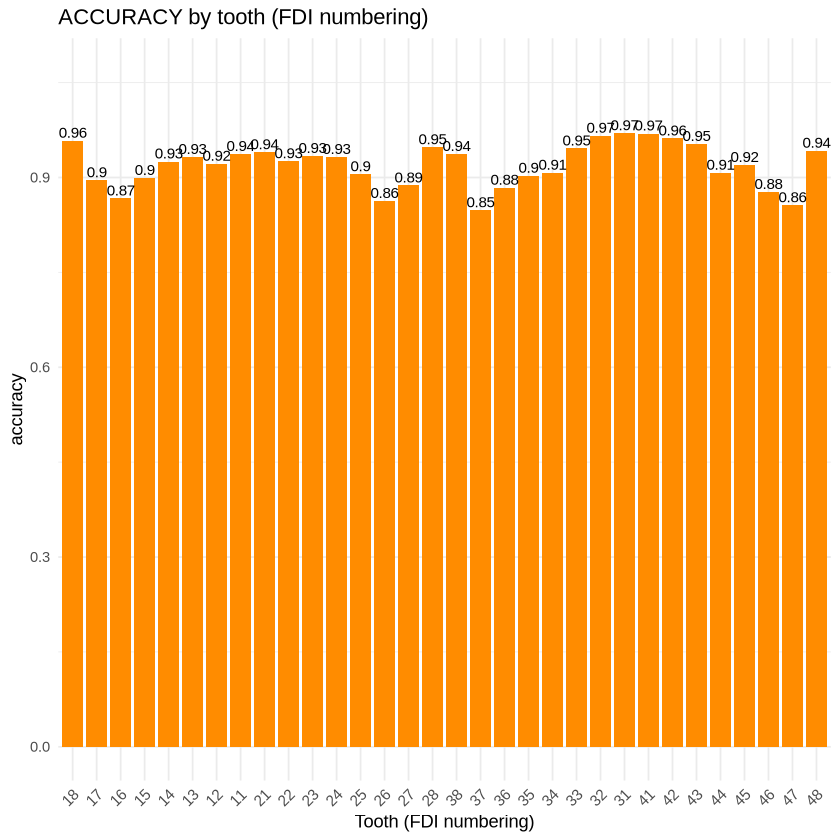

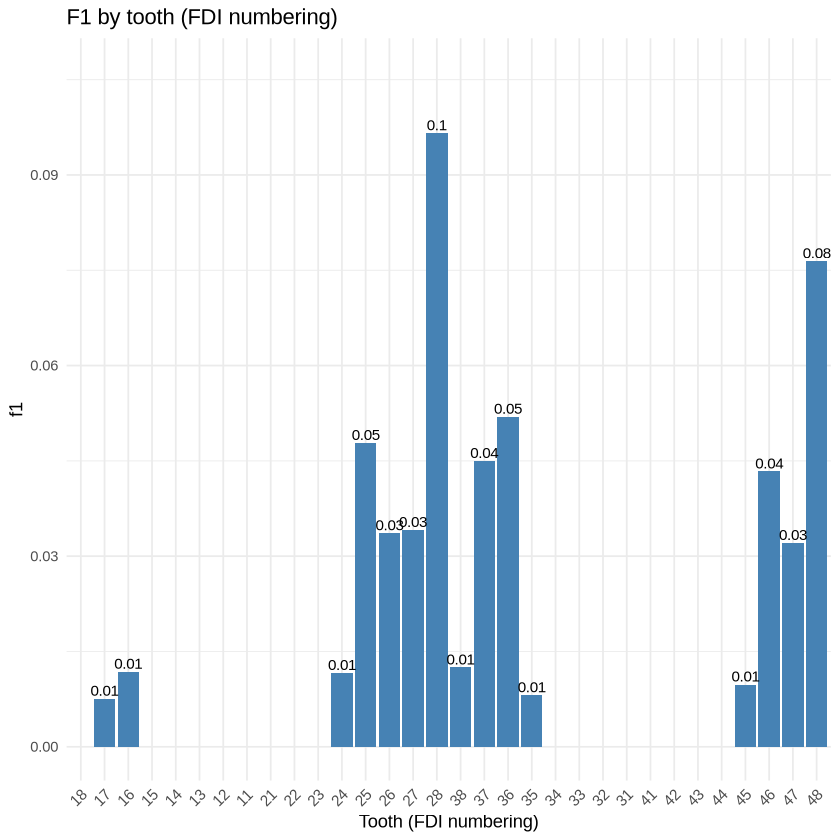

In [61]:
plot_metric_by_tooth(resultado_carie, metric = "accuracy", color = "darkorange")
plot_metric_by_tooth(resultado_carie, metric = "f1", color = "steelblue")

In [62]:
resumo_carie <- aggregate_macro_micro(resultado_carie)

[1] "Resumo global (macro e micro):"
# A tibble: 2 × 6
  agg   precision  recall     f1 accuracy
  <chr>     <dbl>   <dbl>  <dbl>    <dbl>
1 macro     0.474 0.00853 0.0348    0.919
2 micro     0.5   0.0103  0.0202    0.919
  description                                                                  
  <chr>                                                                        
1 Average of metrics across all teeth (each tooth has equal weight)            
2 Global metrics considering all teeth together (weighted by number of samples)


#### Considerando somente a quantidade absoluta de cariados por indivíduo

In [63]:
resultado_carie_count = compute_counts_by_exam(gabarito, predicao, prefix = "carie")

prefix,n_exames,exact_match_rate,mae,rmse,bias
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
carie,2515,0.2759443,2.533201,3.737032,-2.527634


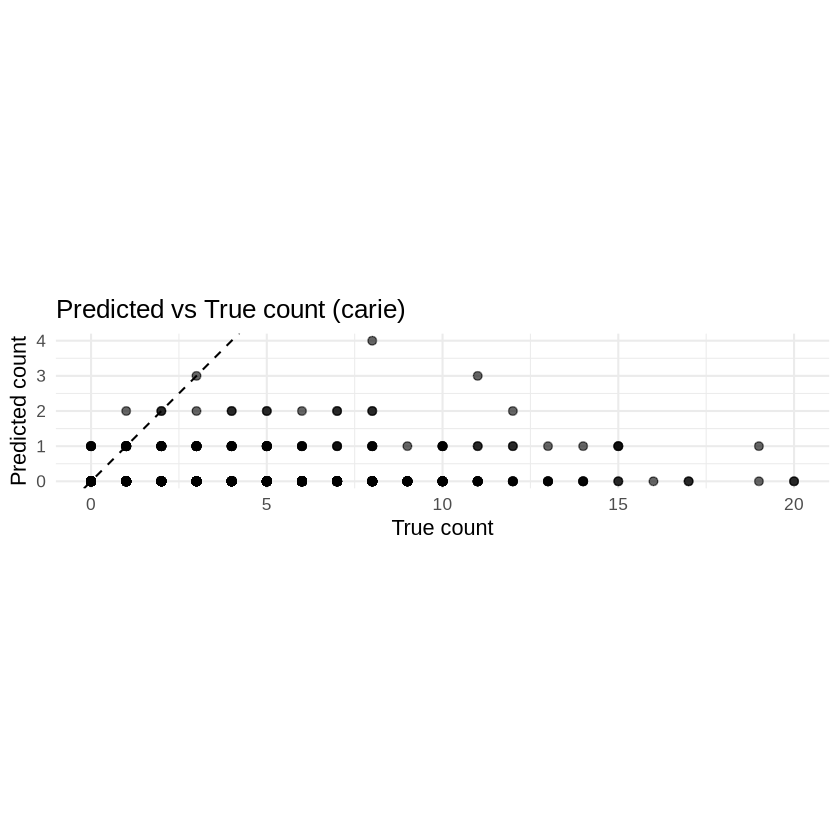

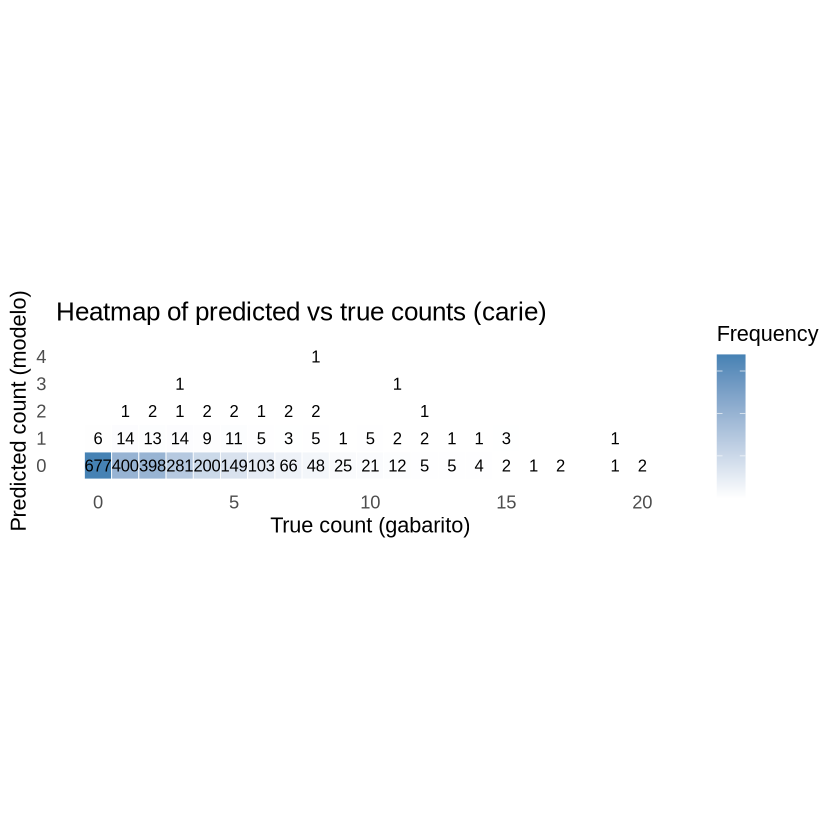

In [64]:
summarize_count_metrics(resultado_carie_count)
plot_counts_scatter(resultado_carie_count)
contingency_table_counts(resultado_carie_count)

### Desempenho do modelo de obturados

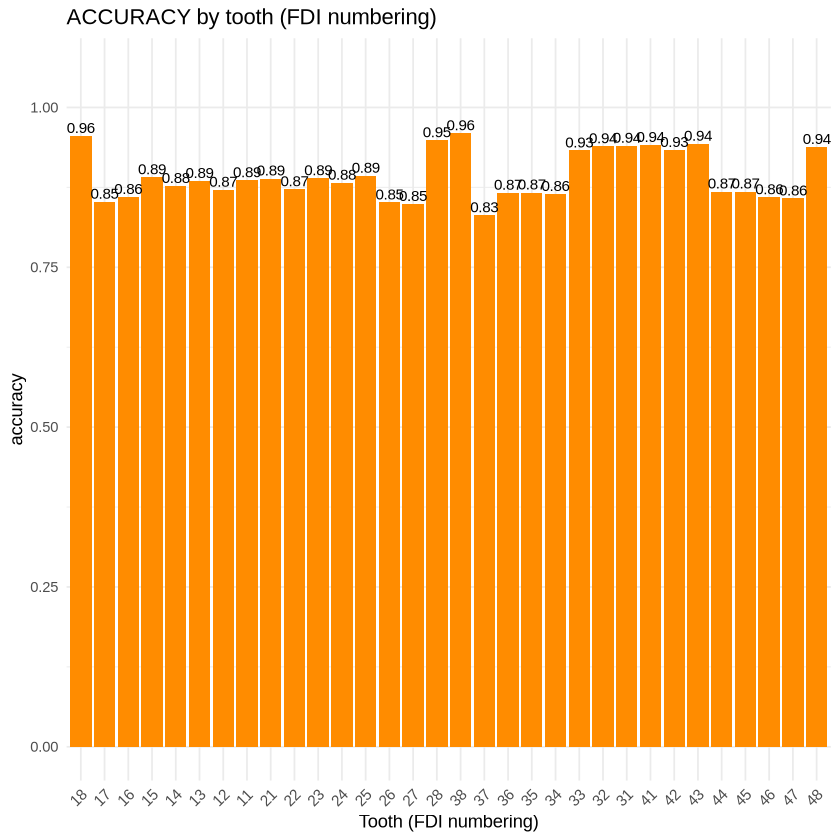

[1] "Resumo global (macro e micro):"
# A tibble: 2 × 6
  agg   precision recall    f1 accuracy
  <chr>     <dbl>  <dbl> <dbl>    <dbl>
1 macro     0.833  0.753 0.781    0.893
2 micro     0.831  0.788 0.809    0.893
  description                                                                  
  <chr>                                                                        
1 Average of metrics across all teeth (each tooth has equal weight)            
2 Global metrics considering all teeth together (weighted by number of samples)


prefix,n_exames,exact_match_rate,mae,rmse,bias
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
obturado,2515,0.1944334,2.005169,2.828357,-0.4870775


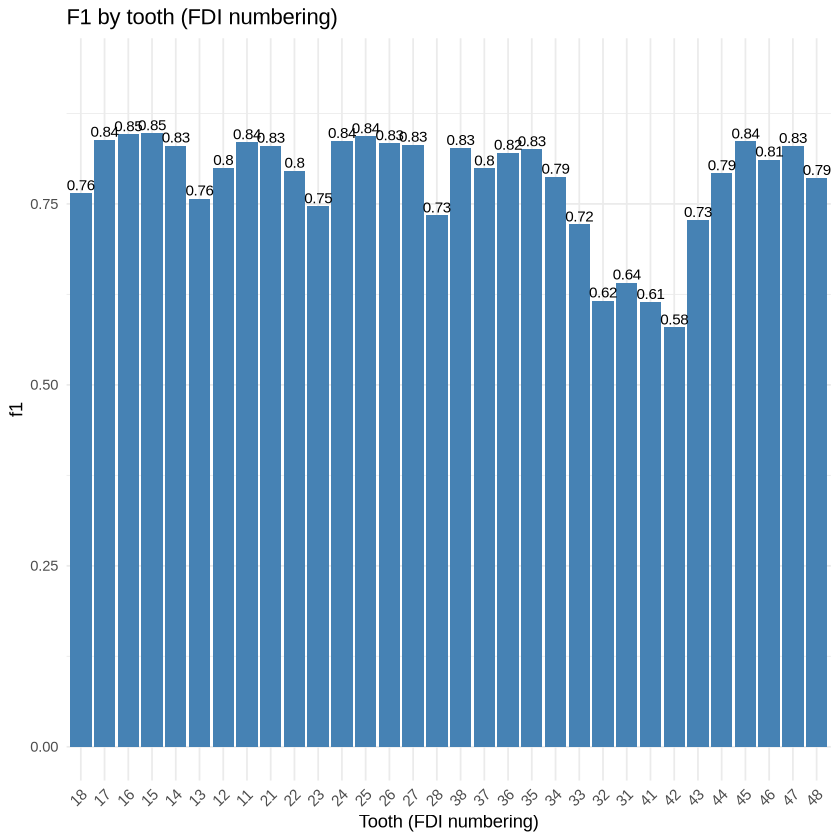

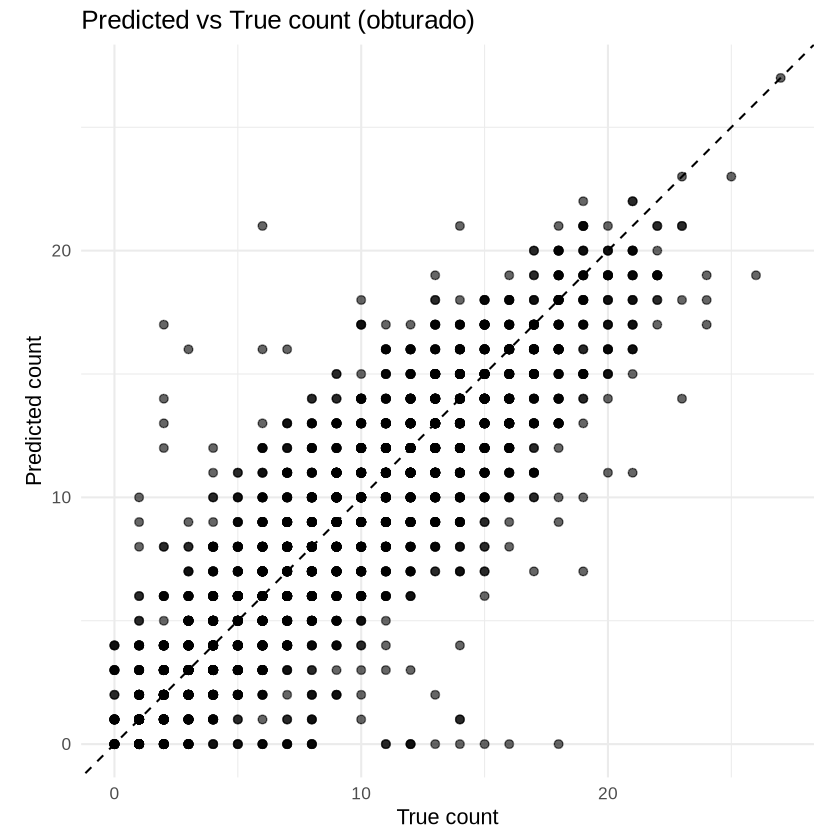

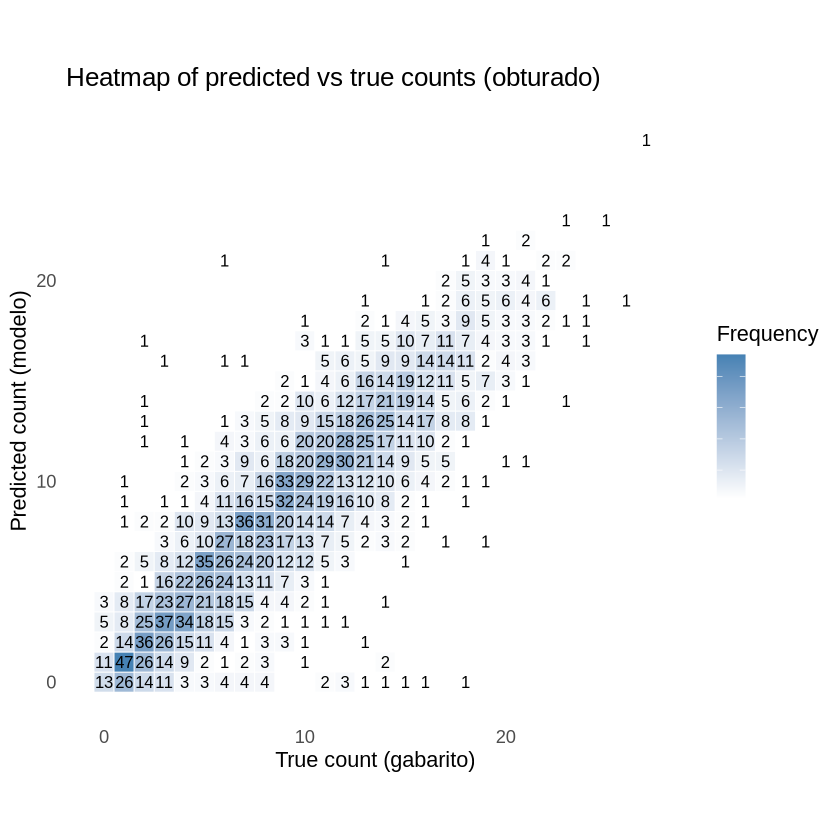

In [65]:
resultado_obturado  <- metrics_by_tooth(gabarito, predicao, prefix = "obturado")
plot_metric_by_tooth(resultado_obturado, metric = "accuracy", color = "darkorange")
plot_metric_by_tooth(resultado_obturado, metric = "f1", color = "steelblue")
resumo_obturado <- aggregate_macro_micro(resultado_obturado)
resultado_obturado_count = compute_counts_by_exam(gabarito, predicao, prefix = "obturado")
summarize_count_metrics(resultado_obturado_count)
plot_counts_scatter(resultado_obturado_count)
contingency_table_counts(resultado_obturado_count)

### Cálculo do CPOD - Gabarito

# A tibble: 6 × 5
  cd_exame   ausentes cariados obturados cpod_total
  <chr>         <dbl>    <dbl>     <dbl>      <dbl>
1 alp.026080        0       14         3         17
2 alp.026233        1        4        11         16
3 alp.026520       13        6         7         26
4 alp.026854        0        2         6          8
5 alp.026933        1        3         2          6
6 alp.027497       12        0        12         24
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.00   13.00   20.00   18.99   25.00   32.00 


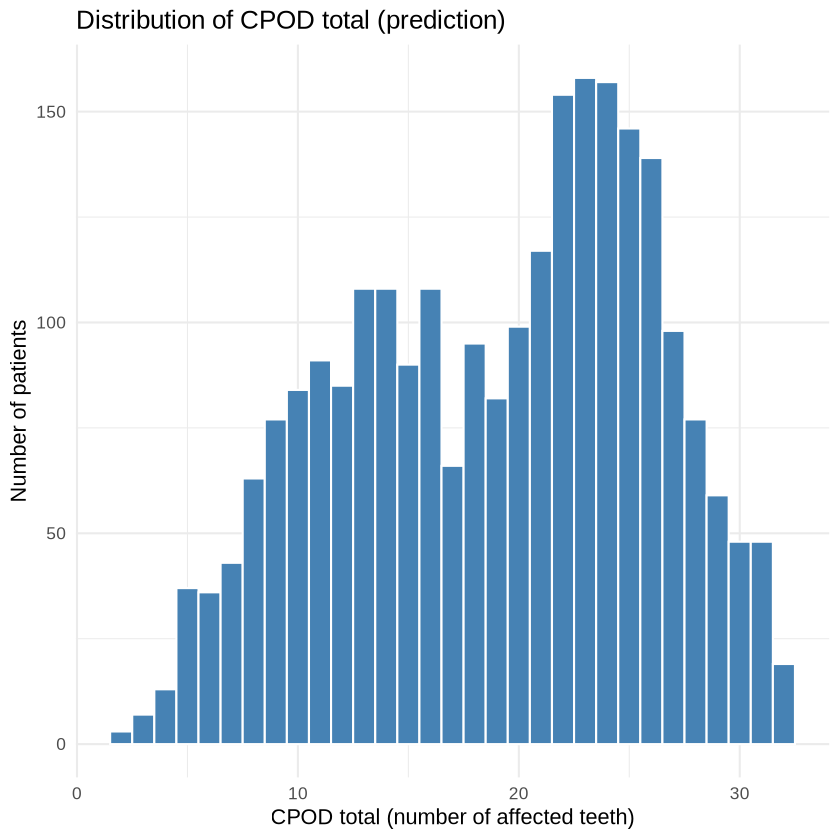

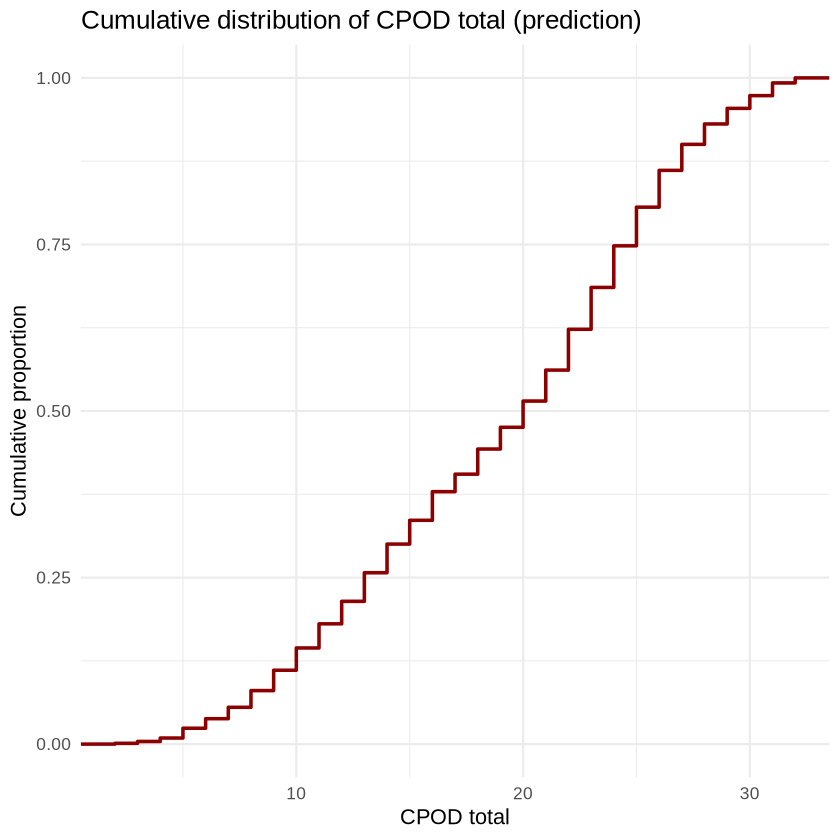

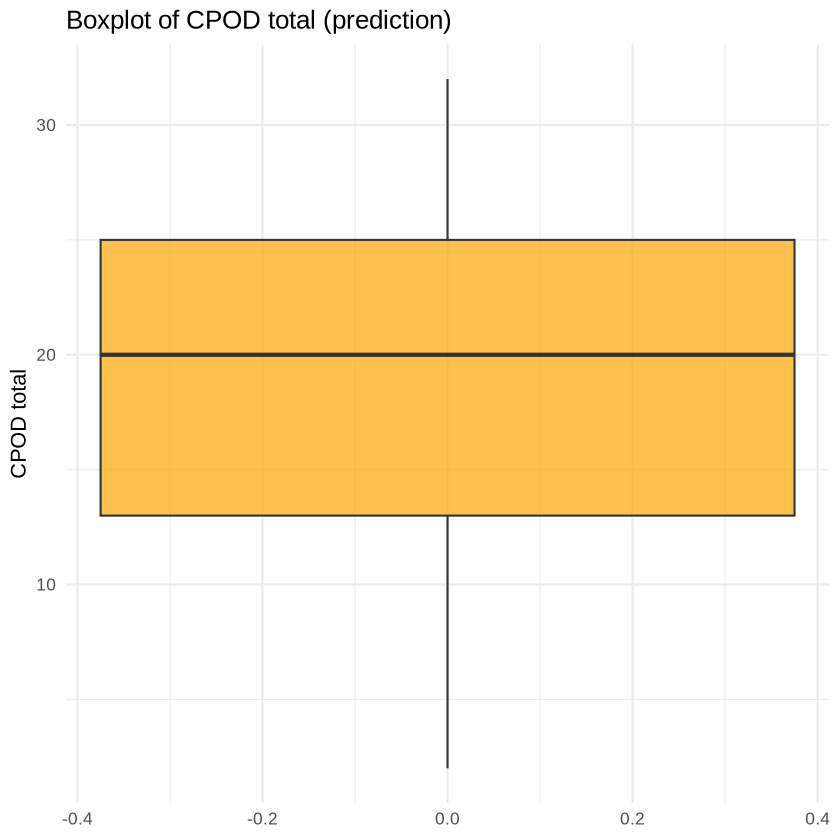

In [66]:
gabarito_cpod = analyze_cpod(gabarito, compute_cpod)

### Cálculo do CPOD - Predição

# A tibble: 6 × 5
  cd_exame   ausentes cariados obturados cpod_total
  <chr>         <dbl>    <dbl>     <dbl>      <dbl>
1 alp.026080        0        1         3          4
2 alp.026233        1        0        10         11
3 alp.026520       10        0        11         21
4 alp.026854        0        1         4          5
5 alp.026933       10        0         2         12
6 alp.027497        9        0        11         20
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   10.00   16.00   14.96   20.00   32.00 


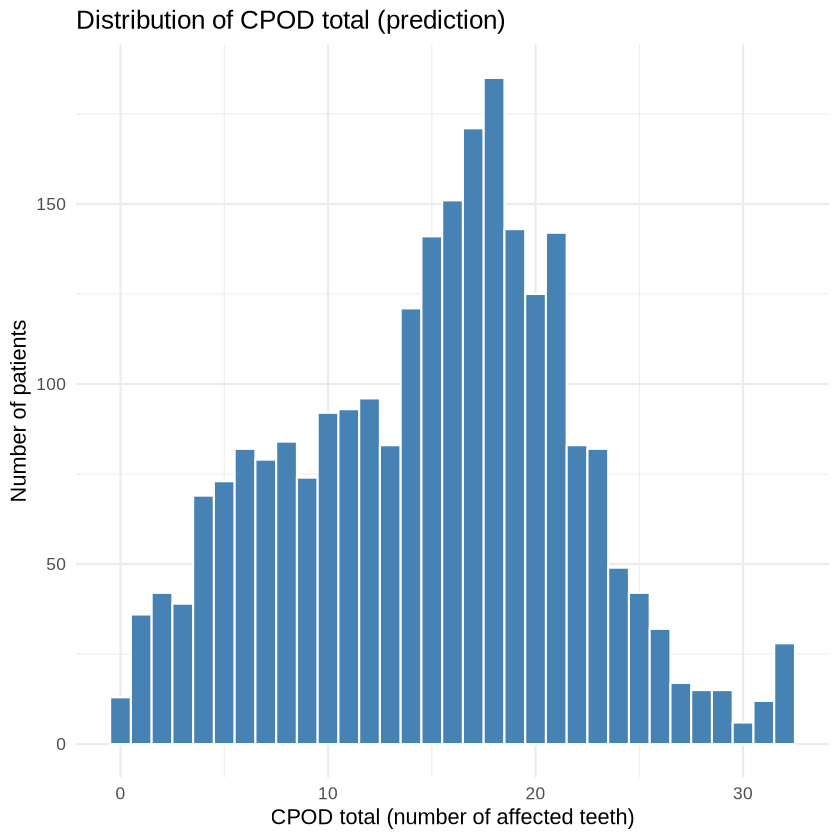

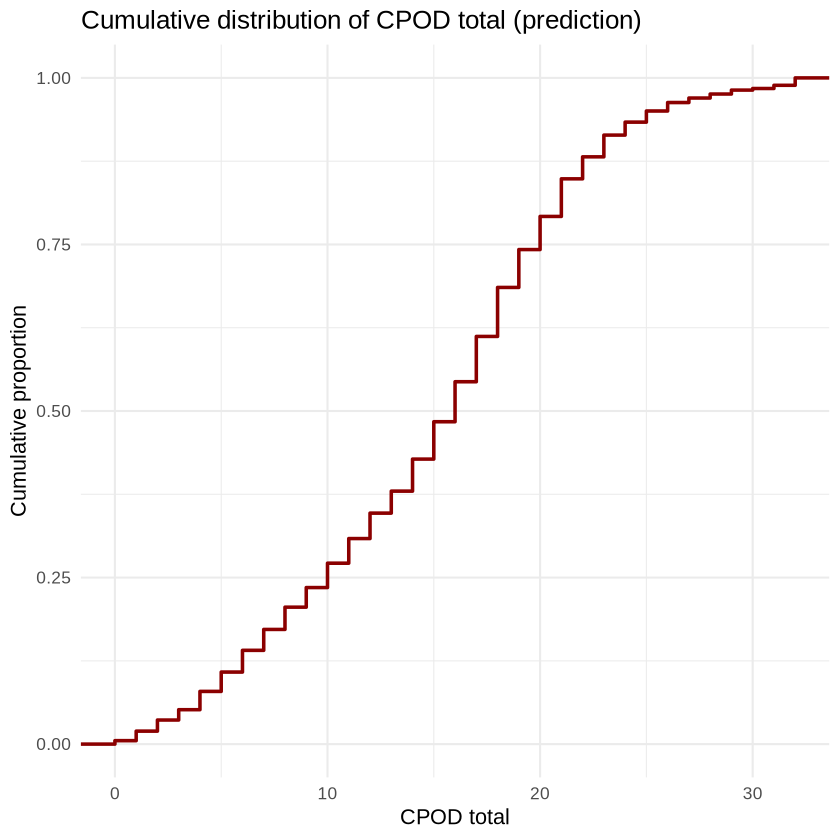

cd_exame,ausentes,cariados,obturados,cpod_total
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
alp.026080,0,1,3,4
alp.026233,1,0,10,11
alp.026520,10,0,11,21
alp.026854,0,1,4,5
alp.026933,10,0,2,12
alp.027497,9,0,11,20


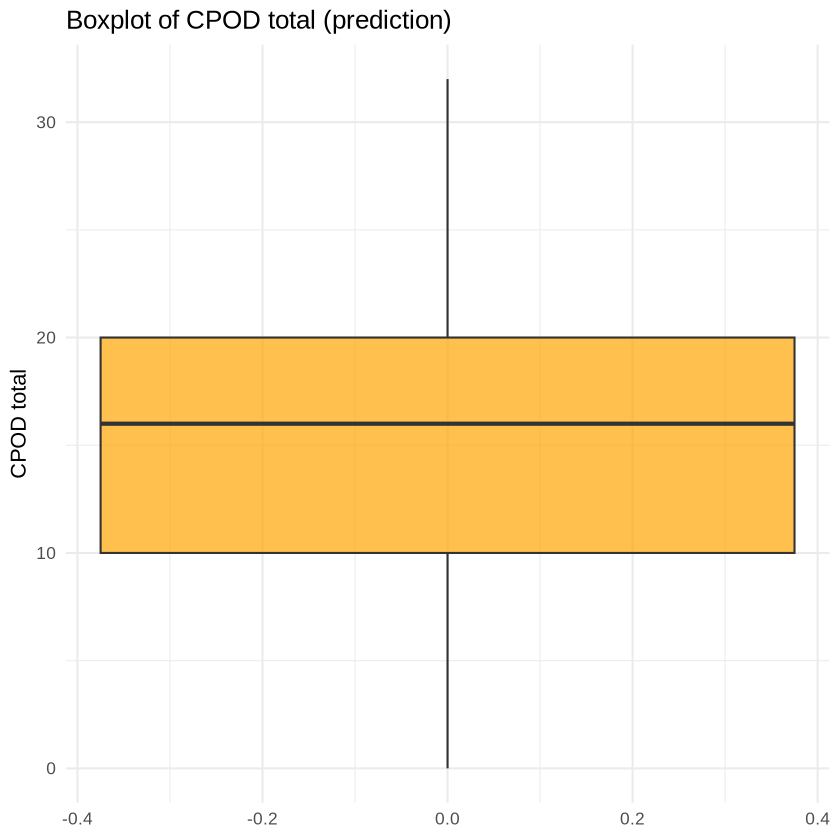

In [67]:
predicao_cpod = analyze_cpod(predicao, compute_cpod)
head(predicao_cpod)

### Cálculo do CPOD - Comparação

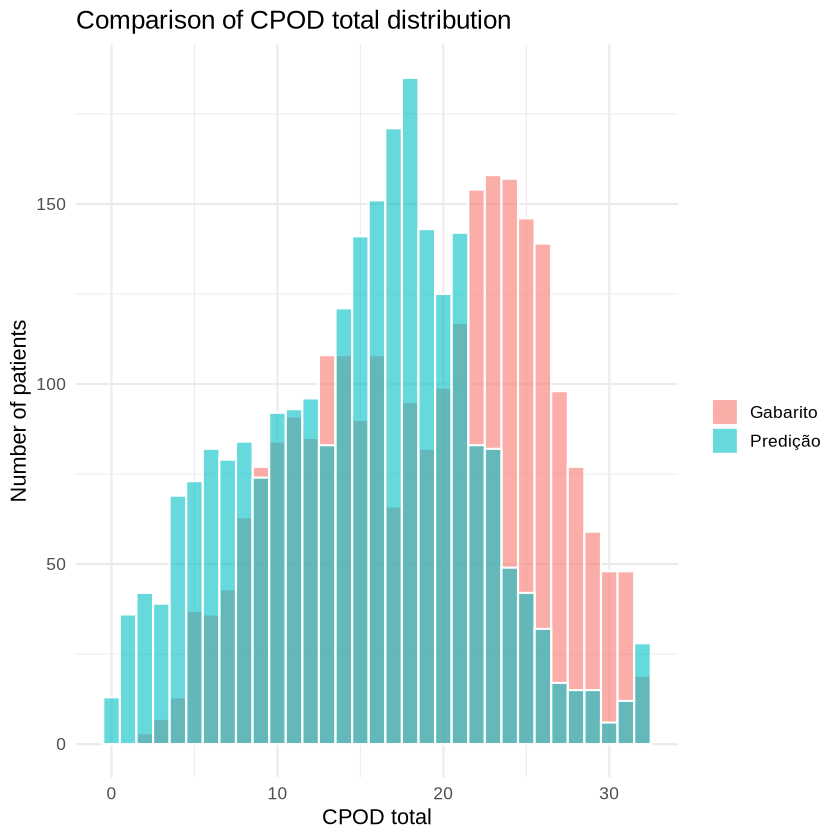

In [68]:
bind_rows(
  gabarito_cpod %>% mutate(tipo = "Gabarito"),
  predicao_cpod %>% mutate(tipo = "Predição")
) %>%
  ggplot(aes(x = cpod_total, fill = tipo)) +
  geom_histogram(binwidth = 1, position = "identity", alpha = 0.6, color = "white") +
  labs(
    title = "Comparison of CPOD total distribution",
    x = "CPOD total",
    y = "Number of patients",
    fill = ""
  ) +
  theme_minimal(base_size = 13)

### Modelo linear para o CPOD (Gabarito)

In [ ]:
gabarito$regiao_sp = factor(x = gabarito$regiao_sp, ordered = FALSE)
gabarito$regiao_sp

In [ ]:
library(dplyr)
library(ggplot2)
library(broom)
library(MASS)

modelar_cpod <- function(gabarito_cpod,
                         gabarito,
                         rhs,                     # ex: "idade + sexo + origem" ou "faixa_etaria * sexo"
                         resultados_modelos,
                         family = c("auto", "gaussian", "negbin"),
                         max_shapiro_n = 5000) {
  
  family <- match.arg(family)
  
  # Garante que a pasta exista
  if (!dir.exists(resultados_modelos)) {
    dir.create(resultados_modelos, recursive = TRUE)
  }
  
  # Monta fórmula completa
  formula_str <- paste("cpod_total ~", rhs)
  fml <- as.formula(formula_str)
  
  # Descobre variáveis explicativas na fórmula
  vars_all <- all.vars(fml)
  vars <- setdiff(vars_all, "cpod_total")
  
  # Verifica se as variáveis existem no gabarito
  missing_vars <- setdiff(vars, names(gabarito))
  if (length(missing_vars) > 0) {
    stop("Variables not found in 'gabarito': ",
         paste(missing_vars, collapse = ", "))
  }
  
  # Une covariáveis por cd_exame
  df <- gabarito_cpod %>%
    inner_join(
      gabarito %>% dplyr::select(cd_exame, dplyr::all_of(vars)),
      by = "cd_exame"
    )
  
  # Teste de normalidade no CPOD total
  x <- df$cpod_total
  x_test <- if (length(x) > max_shapiro_n) sample(x, max_shapiro_n) else x
  normal_test <- shapiro.test(x_test)
  cat("Shapiro-Wilk p-value:", round(normal_test$p.value, 5), "\n")
  
  # Define família
  if (family == "gaussian") {
    chosen <- "gaussian"
  } else if (family == "negbin") {
    chosen <- "negbin"
  } else {
    chosen <- if (normal_test$p.value > 0.05) "gaussian" else "negbin"
  }
  
  # Ajusta modelo
  if (chosen == "gaussian") {
    message("Distribution ~ normal — fitting Linear Model (LM) with formula: ", formula_str)
    modelo <- lm(fml, data = df)
  } else {
    message("Distribution not normal — fitting Negative Binomial Model with formula: ", formula_str)
    modelo <- MASS::glm.nb(fml, data = df)
  }
  
  # Resumo do modelo
  print(summary(modelo))
  coef_tbl <- broom::tidy(modelo, conf.int = TRUE)
  print(coef_tbl)
  
  ##-----------------------------------
  ## GRÁFICOS PRINCIPAIS POR VARIÁVEL
  ##-----------------------------------
  
  plot_list <- list()
  
  for (v in vars) {
    vec <- df[[v]]
    fname_safe <- gsub("[^A-Za-z0-9_]+", "_", v)
    
    if (is.numeric(vec)) {
      p <- ggplot(df, aes(x = .data[[v]], y = cpod_total)) +
        geom_point(alpha = 0.5) +
        geom_smooth(method = "lm", color = "steelblue") +
        labs(
          title = paste("DMFT vs", v),
          x = v,
          y = "DMFT Total"
        ) +
        theme_minimal(base_size = 13)
      
      file_out <- file.path(resultados_modelos, paste0("dmft_vs_", fname_safe, ".png"))
    } else {
      p <- ggplot(df, aes(x = .data[[v]], y = cpod_total, fill = .data[[v]])) +
        geom_boxplot(alpha = 0.7) +
        labs(
          title = paste("DMFT by", v),
          x = v,
          y = "DMFT Total"
        ) +
        theme_minimal(base_size = 13) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
      
      file_out <- file.path(resultados_modelos, paste0("dmft_by_", fname_safe, ".png"))
    }
    
    print(p)
    ggsave(file_out, p, width = 6.5, height = 4.5, dpi = 300)
    message("Saved plot: ", normalizePath(file_out))
    
    plot_list[[v]] <- p
  }
  
  ##-----------------------------
  ## DIAGNÓSTICO DE RESÍDUOS
  ##-----------------------------
  
  message("\n### Diagnostic analysis (plots will be saved)\n")
  diag_plots <- list()
  
  if (inherits(modelo, "lm")) {
    tipo <- "lm"
  } else {
    tipo <- "glm"
  }
  
  if (chosen == "gaussian") {
    # LM padrão
    df_diag <- broom::augment(modelo)
    
    # 1. Residuals vs Fitted
    p1 <- ggplot(df_diag, aes(.fitted, .resid)) +
      geom_point(alpha = 0.5) +
      geom_hline(yintercept = 0, color = "red") +
      labs(title = "Residuals vs Fitted", x = "Fitted values", y = "Residuals") +
      theme_minimal(base_size = 13)
    print(p1)
    ggsave(file.path(resultados_modelos, "diag_residuals_vs_fitted.png"),
           p1, width = 6, height = 4, dpi = 300)
    
    # 2. QQ-Plot
    p2 <- ggplot(df_diag, aes(sample = .std.resid)) +
      stat_qq() + stat_qq_line(color = "red") +
      labs(title = "Normal Q-Q Plot", x = "Theoretical quantiles", y = "Standardized residuals") +
      theme_minimal(base_size = 13)
    print(p2)
    ggsave(file.path(resultados_modelos, "diag_qqplot_residuals.png"),
           p2, width = 6, height = 4, dpi = 300)
    
    # 3. Scale–Location
    p3 <- ggplot(df_diag, aes(.fitted, sqrt(abs(.std.resid)))) +
      geom_point(alpha = 0.5) +
      geom_smooth(method = "loess", se = FALSE, color = "red") +
      labs(title = "Scale-Location Plot",
           x = "Fitted values",
           y = "√|Standardized residuals|") +
      theme_minimal(base_size = 13)
    print(p3)
    ggsave(file.path(resultados_modelos, "diag_scale_location.png"),
           p3, width = 6, height = 4, dpi = 300)
    
    # 4. Residuals vs Leverage
    p4 <- ggplot(df_diag, aes(.hat, .std.resid)) +
      geom_point(alpha = 0.5) +
      labs(title = "Residuals vs Leverage", x = "Leverage", y = "Standardized residuals") +
      theme_minimal(base_size = 13)
    print(p4)
    ggsave(file.path(resultados_modelos, "diag_residuals_vs_leverage.png"),
           p4, width = 6, height = 4, dpi = 300)
    
    diag_plots <- list(resid_vs_fitted = p1,
                       qqplot = p2,
                       scale_loc = p3,
                       resid_vs_leverage = p4)
    
  } else if (chosen == "negbin") {
    # Binomial negativa
    df_diag <- broom::augment(modelo, type.residuals = "pearson")
    
    # 1. Pearson residuals vs fitted
    p1 <- ggplot(df_diag, aes(.fitted, .resid)) +
      geom_point(alpha = 0.5) +
      geom_hline(yintercept = 0, color = "red") +
      labs(title = "Pearson residuals vs Fitted",
           x = "Fitted values", y = "Pearson residuals") +
      theme_minimal(base_size = 13)
    print(p1)
    ggsave(file.path(resultados_modelos, "diag_nb_pearson_vs_fitted.png"),
           p1, width = 6, height = 4, dpi = 300)
    
    # 2. QQ-plot residuals
    p2 <- ggplot(df_diag, aes(sample = .resid)) +
      stat_qq() + stat_qq_line(color = "red") +
      labs(title = "Residuals Q-Q Plot",
           x = "Theoretical quantiles", y = "Residuals") +
      theme_minimal(base_size = 13)
    print(p2)
    ggsave(file.path(resultados_modelos, "diag_nb_qqplot_residuals.png"),
           p2, width = 6, height = 4, dpi = 300)
    
    # 3. Histogram residuals
    p3 <- ggplot(df_diag, aes(x = .resid)) +
      geom_histogram(bins = 40, fill = "steelblue", color = "white") +
      labs(title = "Histogram of residuals", x = "Residuals", y = "Count") +
      theme_minimal(base_size = 13)
    print(p3)
    ggsave(file.path(resultados_modelos, "diag_nb_hist_residuals.png"),
           p3, width = 6, height = 4, dpi = 300)
    
    # 4. Cook’s distance
    cooks <- cooks.distance(modelo)
    df_cook <- tibble(index = seq_along(cooks), cook = cooks)
    
    p4 <- ggplot(df_cook, aes(index, cook)) +
      geom_point(alpha = 0.6) +
      labs(title = "Cook's Distance", x = "Observation index", y = "Cook's distance") +
      theme_minimal(base_size = 13)
    print(p4)
    ggsave(file.path(resultados_modelos, "diag_nb_cooks_distance.png"),
           p4, width = 6, height = 4, dpi = 300)
    
    diag_plots <- list(pearson_vs_fitted = p1,
                       qqplot = p2,
                       hist_resid = p3,
                       cooks = p4)
  }
  
  return(list(
    modelo = modelo,
    normality_test = normal_test,
    dados = df,
    formula = fml,
    family_chosen = chosen,
    coeficientes = coef_tbl,
    main_plots = plot_list,
    diagnostic_plots = diag_plots
  ))
}


#### CPOD - Idade, sexo e origem

In [ ]:
resultados_modelos <- "/home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_modelos/cpdo_idade_sexo_origem"

resultado_modelo <- modelar_cpod(gabarito_cpod, gabarito, "idade + sexo + origem", resultados_modelos)

#### CPOD - Faixa etaria, sexo e origem

In [ ]:
gabarito$faixa_etaria = factor(gabarito$faixa_etaria,ordered = FALSE)
gabarito$faixa_etaria

In [ ]:
resultados_modelos <- "/home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_modelos/cpdo_faixa_sexo_origem"

resultado_modelo <- modelar_cpod(gabarito_cpod, gabarito, "faixa_etaria + sexo + origem", resultados_modelos)

#### CPOD - idade, sexo e regiao_sp

In [ ]:
resultados_modelos <- "/home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_modelos/cpdo_idade_sexo_regiao_sp"

resultado_modelo <- modelar_cpod(gabarito_cpod, gabarito, "idade + sexo + regiao_sp", resultados_modelos)

#### CPOD - Faixa etaria, sexo e regiao sp

In [ ]:
resultados_modelos <- "/home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_modelos/cpdo_faixa_sexo_regiao_sp"

resultado_modelo <- modelar_cpod(gabarito_cpod, gabarito, "faixa_etaria + sexo + regiao_sp", resultados_modelos)

#### CPOD - Faixa etaria, sexo e origem

In [ ]:
resultados_modelos <- "/home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_modelos/cpdo_faixa_sexo_regiao_sp_faixa*sexo"

resultado_modelo <- modelar_cpod(gabarito_cpod, gabarito, "faixa_etaria + sexo + regiao_sp + faixa_etaria * sexo ", resultados_modelos)

In [ ]:
resultados_modelos <- "/home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_modelos/cpdo_idade_sexo_regiao_faixa*sexo"

resultado_modelo <- modelar_cpod(gabarito_cpod, gabarito, "idade + sexo + idade*sexo + regiao_sp  ", resultados_modelos)

In [ ]:
resultados_modelos <- "/home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_modelos/cpdo_idade_sexo_origem_faixa*sexo"

resultado_modelo <- modelar_cpod(gabarito_cpod, gabarito, "idade + sexo + idade*sexo + origem", resultados_modelos,family = "gaussian")

In [ ]:
resultados_modelos <- "/home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_modelos/cpdo_faixa_etaria_sexo_regiao_faixa*sexo"

resultado_modelo <- modelar_cpod(gabarito_cpod, gabarito, "faixa_etaria + sexo + faixa_etaria*sexo + regiao_sp  ", resultados_modelos, family = "gaussian")

- Tentar:
*colocar o ponto médio da faixa etaria
*colocar o ponto maximo da faixa etaria
*classes discretas (1,2,3,4,5)
*ver uma funcao que as variancias sao diferentes (lme)

*descrever a heterocedasticidade

In [ ]:
gabarito

### Modelo Dirichlet-Multinomial

In [ ]:
library(dplyr)

# Conferir estrutura de gabarito_cpod
glimpse(gabarito_cpod)

# Conferir algumas linhas
head(gabarito_cpod)

# Checar se não tem NA bizarro nas contagens
summary(gabarito_cpod[, c("ausentes", "cariados", "obturados", "cpod_total")])

In [ ]:
library(MGLM)

# Mantém só as colunas que importam
dm_df <- gabarito_cpod %>%
  dplyr::select(cd_exame, ausentes, cariados, obturados) %>%
  dplyr::mutate(
    total = ausentes + cariados + obturados
  ) %>%
  dplyr::filter(total > 0)  # remove linhas com tudo zero

# Ajuste do modelo Dirichlet-Multinomial com **apenas intercepto**
modelo_dm0 <- MGLMreg(
  as.matrix(dm_df[, c("ausentes", "cariados", "obturados")]) ~ 1,
  data = dm_df,
  dist = "DM"
)

summary(modelo_dm0)

In [ ]:
# Junta CPOD com idade e sexo
dm_df2 <- gabarito_cpod %>%
  dplyr::inner_join(
    gabarito %>% dplyr::select(cd_exame, idade, sexo),
    by = "cd_exame"
  ) %>%
  dplyr::mutate(
    total = ausentes + cariados + obturados
  ) %>%
  dplyr::filter(total > 0)

# Matriz Y multivariada
Y2 <- as.matrix(dm_df2[, c("ausentes", "cariados", "obturados")])

# Ajuste do modelo com idade + sexo como covariáveis
modelo_dm1 <- MGLMreg(
  Y2 ~ idade + sexo,
  data = dm_df2,
  dist = "DM"
)

summary(modelo_dm1)
coef(modelo_dm1)

In [ ]:
dm_df2_prop <- dm_df2 %>%
  dplyr::mutate(
    prop_ausentes  = ausentes  / total,
    prop_cariados  = cariados  / total,
    prop_obturados = obturados / total
  )

# Estatísticas por sexo (exemplo)
dm_df2_prop %>%
  dplyr::group_by(sexo) %>%
  dplyr::summarise(
    n = n(),
    mean_missing = mean(prop_ausentes),
    mean_decayed = mean(prop_cariados),
    mean_filled  = mean(prop_obturados)
  )

In [ ]:
# mesma fórmula do ajuste
rhs <- "~ idade + sexo"

# matriz de design numérica
X2 <- model.matrix(as.formula(rhs), data = dm_df2)

# conferir dimensões
dim(X2)
coef(modelo_dm1)  # opcional: ver quantas linhas tem


In [ ]:
fitted_counts2 <- predict(modelo_dm1, newdata = X2)
fitted_counts2 <- as.matrix(fitted_counts2)

# conferir estrutura
dim(fitted_counts2)
head(fitted_counts2)


In [ ]:
row_totals2 <- rowSums(fitted_counts2)
fitted_prop2 <- fitted_counts2 / row_totals2
colnames(fitted_prop2) <- c("fit_ausentes", "fit_cariados", "fit_obturados")

df_diag2 <- dm_df2_prop %>%
  dplyr::bind_cols(as.data.frame(fitted_prop2))

In [ ]:
ggplot(df_diag2, aes(x = prop_ausentes, y = fit_ausentes)) +
  geom_point(alpha = 0.4) +
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
  labs(
    title = "Observed vs Fitted (missing teeth)",
    x = "Observed proportion",
    y = "Fitted proportion"
  ) +
  theme_minimal(base_size = 13)

In [ ]:
library(dplyr)
library(tidyr)
library(MGLM)

modelar_cpod_dm <- function(cpod_df,
                            gabarito,
                            rhs) {
  # cpod_df: data.frame com cd_exame, ausentes, cariados, obturados (e cpod_total se quiser)
  # gabarito: data.frame com cd_exame e variáveis explicativas (idade, sexo, etc.)
  # rhs: string com o lado direito da fórmula, ex: "idade + sexo + regiao_sp"
  
  # Colunas de resposta esperadas
  resp_cols <- c("ausentes", "cariados", "obturados")
  if (!all(resp_cols %in% names(cpod_df))) {
    stop("cpod_df must contain columns: ", paste(resp_cols, collapse = ", "))
  }
  
  # Fórmula só do lado direito para extrair variáveis
  rhs_form <- as.formula(paste("~", rhs))
  vars_all <- all.vars(rhs_form)
  
  # Verifica se variáveis existem no gabarito
  missing_vars <- setdiff(vars_all, names(gabarito))
  if (length(missing_vars) > 0) {
    stop("Variables not found in 'gabarito': ",
         paste(missing_vars, collapse = ", "))
  }
  
  # Junta CPOD com covariáveis
  df <- cpod_df %>%
    dplyr::inner_join(
      gabarito %>% dplyr::select(cd_exame, dplyr::all_of(vars_all)),
      by = "cd_exame"
    ) %>%
    dplyr::mutate(
      total = ausentes + cariados + obturados
    ) %>%
    dplyr::filter(total > 0)
  
  # Matriz de resposta Y (3 colunas)
  Y_mat <- as.matrix(df[, resp_cols])
  
  # Fórmula completa para o MGLMreg (lado esquerdo é o objeto Y_mat)
  fml <- as.formula(paste("Y_mat ~", rhs))
  
  # Ajusta o modelo Dirichlet–Multinomial
  modelo <- MGLMreg(fml, data = df, dist = "DM")
  
  # Coeficientes em formato “tidy”
  coef_raw <- coef(modelo)  # deve ser matriz: linhas = parâmetros, colunas = componentes
  if (!is.matrix(coef_raw)) {
    stop("Unexpected coef(modelo): expected a matrix.")
  }
  
  coef_tbl <- as_tibble(coef_raw, rownames = "term") %>%
    tidyr::pivot_longer(
      cols = -term,
      names_to = "component",
      values_to = "estimate"
    )
  
  # Proporções observadas
  df_prop <- df %>%
    dplyr::mutate(
      prop_ausentes  = ausentes  / total,
      prop_cariados  = cariados  / total,
      prop_obturados = obturados / total
    )
  
  # Predição: precisa da mesma matriz de design usada no ajuste
  X_new <- model.matrix(rhs_form, data = df)
  fitted_counts <- predict(modelo, newdata = X_new)
  fitted_counts <- as.matrix(fitted_counts)
  
  row_tot <- rowSums(fitted_counts)
  fitted_prop <- fitted_counts / row_tot
  colnames(fitted_prop) <- c("fit_ausentes", "fit_cariados", "fit_obturados")
  
  df_diag <- df_prop %>%
    dplyr::bind_cols(as.data.frame(fitted_prop))
  
  # Retorna tudo organizado
  list(
    formula_rhs  = rhs,
    modelo       = modelo,
    coeficientes = coef_tbl,
    dados        = df,
    proporcoes   = df_prop,  # observado
    diag         = df_diag   # observado + ajustado
  )
}


In [ ]:
resultados_dm <- "/home/aninha/Desktop/Doutorado/Doutorado/671c01c3e2bfd3dd5c5f565e/imagens_modelos/dm_faixa_etaria_sexo_regiao_sp"

res_dm <- modelar_cpod_dm(
  cpod_df  = gabarito_cpod,
  gabarito = gabarito,
  rhs      = "idade + sexo"
)

names(res_dm)
res_dm$coeficientes
head(res_dm$diag)

### Modelo trinomial VGLM

In [ ]:
dados = merge(gabarito, gabarito_cpod, by="cd_exame")
head(dados)

In [ ]:
dados2 = dados[,c("ausentes","cariados", "obturados", "faixa_etaria", "sexo", "regiao_sp")]
head(dados2)

In [ ]:
summary(dados2)

dados2$faixa_etaria = as.factor(dados2$faixa_etaria)
dados2$sexo = as.factor(dados2$sexo)
dados2$regiao_sp = as.factor(dados2$regiao_sp)
summary(dados2)


In [ ]:
## MODELAGEM VGLM - TRINOMIAL##
library(VGAM)
library(gamlss)
options(scipen = 999)
# Variável resposta 
#Primeiro modelo trinomial com todos os dados
fit1 = vglm(ausentes ~ faixa_etaria + sexo + regiao_sp,
            family = negbinomial, data = dados2)
#obs: refLevel = 1 dentro da função multinomial() coloca o nível 1 como referência, nesse caso o Não
#Abaixo a função stepaic do pacote VGAM
fit2 = step4vglm(fit1, direction = "both")
fit2@call
# #A saída da função da linha 351 se encontra abaixo
# fit2 = vglm(Gravidez ~ Sexo + Intimidade_responsável + Ouvir_HIV + 
#               Ouvir_preservativo + Saber_preservativo + Saber_contracepção + 
#               Escore_liberdade + Escore_voz, family = multinomial(refLevel = 1), data = dados3_imp)
# summary(fit2)
# #Razão de chances
# exp(coef(fit2, matrix=TRUE))
# deviance(fit2)
# df.residual(fit2)

# #Modelos binomiais (marginais) apenas para fins de diagnóstico
# #Modelo Não/Sim
# fit2.1 = gamlss(formula = Gravidez ~ Sexo + Intimidade_responsável + 
#                   Ouvir_HIV + Ouvir_preservativo + Saber_preservativo + Saber_contracepção + 
#                   Escore_liberdade + Escore_voz, family = BI, data = dados3_imp_grav_sim)
# summary(fit2.1)
# #Resíduos quantílicos
# plot(fit2.1)
# #Wormplot
# wp(fit2.1)

# #Modelo Não/Outros
# fit2.2 = gamlss(formula = Gravidez ~ Sexo + Intimidade_responsável + 
#                   Ouvir_HIV + Ouvir_preservativo + Saber_preservativo + Saber_contracepção + 
#                   Escore_liberdade + Escore_voz, family = BI, data = dados3_imp_grav_outros)
# summary(fit2.2)
# plot(fit2.2)
# wp(fit2.2)

# #Resíduos de Pearson
# rp2 <- residuals(fit2, type = "pearson")
# par(mfrow = c(1, 2))
# plot(rp2[,1], pch=20, xlab="Índice", ylab="Resíduos de Pearson")
# abline(h=0, col = "red")
# title("Logito 1")
# plot(rp2[,2], pch=20, xlab="Índice", ylab="Resíduos de Pearson")
# abline(h=0, col = "red")
# title("Logito 2")
# par(mfrow = c(1, 1))

# #Calculando as previsões do modelo'
# pred_class2 = predict(fit2, newdata = dados3_imp, type = "response")
# predicted_labels2 <- factor(apply(pred_class2, 1, which.max),
#                             levels = 1:nlevels(dados3_imp$Gravidez),
#                             labels = levels(dados3_imp$Gravidez))
# actual_labels2 <- dados3_imp$Gravidez

# #Matriz de confusão
# library(caret)
# confusion_matrix_result2 <- confusionMatrix(data = predicted_labels2, reference = actual_labels2)
# confusion_matrix_result2'

In [ ]:
dim(dados2)

In [ ]:
df_prop <- dados2 %>%
  mutate(
    total = cariados + ausentes + obturados,
    pC = cariados  / total,
    pP = ausentes  / total,
    pD = obturados / total
  ) %>%
  filter(total > 0)

head(df_prop)

In [ ]:
Y <- as.matrix(df_prop[, c("cariados", "ausentes", "obturados")])
head(Y)

In [ ]:
df_prop$faixa_etaria = factor(df_prop$faixa_etaria, ordered=FALSE)

In [ ]:
fit1 <- vglm(
    Y ~ faixa_etaria + sexo + regiao_sp,
    family = multinomial(refLevel = 1),  # 1 = cariado
    data = df_prop
  )
  fit1

In [ ]:
fit2 = step4vglm(fit1, direction = "both")
fit2@call
summary(fit2)

In [ ]:
#Resíduos de Pearson
rp2 <- residuals(fit2, type = "pearson")
par(mfrow = c(1, 2))
plot(rp2[,1], pch=20, xlab="Índice", ylab="Resíduos de Pearson")
abline(h=0, col = "red")
title("Logito 1")
plot(rp2[,2], pch=20, xlab="Índice", ylab="Resíduos de Pearson")
abline(h=0, col = "red")
title("Logito 2")
par(mfrow = c(1, 1))

### Modelo misto

In [ ]:
avaliar_ausentes_por_dente <- function(gabarito) {
  
  # Seleciona apenas colunas "ausente_XX"
  cols_aus <- grep("^ausente_\\d{2}$", names(gabarito), value = TRUE)
    
  # Converte para inteiro e soma por dente
  ausentes_sum <- gabarito %>%
    summarise(across(all_of(cols_aus), ~ sum(as.numeric(.x) > 0, na.rm = TRUE))) %>%
    tidyr::pivot_longer(cols = everything(),
                        names_to = "dente_col",
                        values_to = "n_ausentes") %>%
    mutate(
      dente = as.integer(stringr::str_extract(dente_col, "\\d{2}"))
    ) %>%
    arrange(desc(n_ausentes))
  
  print("Tabela de frequência de dentes ausentes (do mais ao menos ausente):")
  print(ausentes_sum, n = Inf)
  
  # Gráfico de barras ordenado
  p <- ggplot(ausentes_sum, aes(x = reorder(factor(dente), -n_ausentes), y = n_ausentes)) +
    geom_col(fill = "darkred") +
    geom_text(aes(label = n_ausentes), vjust = -0.3, size = 3.2) +
    labs(
      title = "Most frequently missing teeth (Ground truth)",
      x = "Tooth (FDI numbering)",
      y = "Number of missing cases"
    ) +
    theme_minimal(base_size = 13)
  
  print(p)
  
  invisible(ausentes_sum)
}

resultado_ausentes <- avaliar_ausentes_por_dente(gabarito)

In [ ]:
resultado_ausentes

In [ ]:
gabarito

In [ ]:
# modelo
# ausente ou nao_dente = origem + idade	+ faixa_etaria_oms + faixa_etaria + sexo + dente

In [ ]:
df_long <- gabarito %>%
    dplyr::select(cd_exame, faixa_etaria, regiao_sp, idade, sexo, origem, starts_with("ausente_")) %>%
    pivot_longer(
      cols = starts_with("ausente_"),
      names_to = "dente_col",
      values_to = "ausente"
    ) %>%
    mutate(
      dente = as.integer(stringr::str_extract(dente_col, "\\d{2}")),
      ausente = as.integer(ausente > 0)
    ) %>%
    drop_na(ausente)

In [ ]:
df_long

In [ ]:
write.csv(
  df_long,
  "/home/aninha/Desktop/Doutorado/Dados/gabarito_foco_ausente.csv",
  row.names = FALSE,
  quote = FALSE
)

In [ ]:
modelo <- glmer(
    ausente ~ dente + sexo + idade + origem + (1 | cd_exame),
    data = df_long,
    family = binomial(link = "logit"),
    control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 1e5))
  )

In [ ]:
modelo <- glmer(
    ausente ~ dente + sexo + faixa_etaria + regiao_sp + (1 | cd_exame),
    data = df_long,
    family = binomial(link = "logit"),
    control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 1e5))
  )

In [ ]:
modelo

In [ ]:
# Coeficientes fixos com OR (odds ratios)
fixef_tbl <- broom.mixed::tidy(modelo, effects = "fixed", conf.int = TRUE, conf.method = "Wald") %>%
mutate(
    OR = exp(estimate),
    OR_low = exp(conf.low),
    OR_high = exp(conf.high)
) %>%
arrange(p.value)

print("Efeitos fixos (Odds Ratios):")
print(fixef_tbl, n = Inf, width = Inf)

In [ ]:
# Efeitos aleatórios
ranef_tbl <- broom.mixed::tidy(modelo, effects = "ran_vals")
print("Efeitos aleatórios:")
print(head(ranef_tbl, 10))

In [ ]:
# Plot dos odds ratios
p_or <- ggplot(fixef_tbl %>% filter(term != "(Intercept)"),
                aes(x = reorder(term, OR), y = OR)) +
geom_point() +
geom_errorbar(aes(ymin = OR_low, ymax = OR_high), width = 0.2) +
geom_hline(yintercept = 1, linetype = "dashed", color = "gray40") +
coord_flip() +
labs(title = "Fixed effects (Odds Ratios) for tooth absence",
        x = "Variable", y = "Odds Ratio (logistic link)") +
theme_minimal(base_size = 13)

print(p_or)

<!-- ### Modelo binomial misto (GLMM)

**Resposta binária:** dente ausente (1) ou presente (0)

**Efeitos fixos:** dente, sexo, idade, origem (região)

**Efeito aleatório:** indivíduo (cd_exame)

**Estrutura hierárquica (nested):** dentes estão aninhados dentro dos indivíduos -->

# Olhar um caso especifico

In [ ]:
exame = "alp.028355"

In [ ]:
gabarito_cpod[gabarito$cd_exame=="alp.028355",]

In [ ]:
gabarito_cpod[gabarito$cd_exame=="alp.028355",]

In [ ]:
predicao_cpod[predicao$cd_exame=="alp.028355",]

In [ ]:
predicao_cpod[predicao$cd_exame=="alp.028355",]

In [ ]:
check_inconsistencias <- function(df) {
  dentes <- c(11:18, 21:28, 31:38, 41:48)
  dentes <- sprintf("%02d", dentes)
  
  any_problem <- FALSE
  
  for (d in dentes) {
    cols_d <- intersect(
      paste0(c("ausente_", "carie_", "obturado_"), d),
      names(df)
    )
    if (length(cols_d) <= 1) next
    
    soma <- rowSums(df[cols_d], na.rm = TRUE)
    if (any(soma > 1)) {
      cat("Ainda há sobreposição no dente", d, "em",
          sum(soma > 1), "exames.\n")
      any_problem <- TRUE
    }
  }
  
  if (!any_problem) cat("Nenhuma sobreposição restante entre ausente/carie/obturado.\n")
}

check_inconsistencias(gabarito)
check_inconsistencias(predicao)